# EDA - Using matched treatment and control groups only

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt 
import pyarrow.parquet as pq
import warnings
warnings.filterwarnings("ignore")
from src.visualization.tariff_plot import plot_monthly_adoption, plot_monthly_share, plot_tariff_group_counts, plot_tariff_group_cumulative 
from src.visualization.consumption_plot import plot_consumption, plot_tariff_adoption_by_usage, plot_event_study_tariff, plot_tariff_adoption
from src.visualization.consumption_cohort import plot_cohort_calendar, plot_multiple_cohorts, plot_cohort_panels
from src.visualization import peak_plot as pp

## Load Data 

### Adopt matching result

In [2]:
import pandas as pd

# matching results
base = "output/matching/summary_1"
matches = pd.read_parquet(f"{base}/matches.parquet")
matches["cohort"] = pd.to_datetime(matches["adoption_month"]).dt.to_period("M") # add!
print(matches.head())

treated_ids = matches["treated_id"].unique()
control_ids = matches["control_id"].unique()
print(f"Treated IDs: {len(treated_ids)}, Control IDs: {len(control_ids)}")

           treated_id          control_id adoption_month  distance   cohort
0  735999166200008643  735999166200020165     2025-03-01  0.105016  2025-03
1  735999166200008643  735999166200348032     2025-03-01  0.110436  2025-03
2  735999166200008643  735999166200190077     2025-03-01  0.123623  2025-03
3  735999166200008643  735999166200009354     2025-03-01  0.125258  2025-03
4  735999166200008643  735999166200360475     2025-03-01  0.125406  2025-03
Treated IDs: 100, Control IDs: 300


### Consumption data

In [3]:
# data paths
DATA_DIR_MOCK = "mock_data"
DATA_DIR_AGG = "output/data"
OUT_BASE_DIR = "output"

# Load aggregated data paths
MATDATA_PATH_MONTHLY = os.path.join(DATA_DIR_AGG, "monthly_agg.parquet")

# Load mock tariff and survey data paths
TARIFF_PATH  = os.path.join(DATA_DIR_MOCK, "tariff_100.csv")
SURVEY_PATH  = os.path.join(DATA_DIR_MOCK, "survey_50.csv")

In [4]:
# Monthly aggregated data
pf = pq.ParquetFile(MATDATA_PATH_MONTHLY)
table = pf.read()
month_result = table.to_pandas()
month_result.head()


,aID,TIDPUNKT,price,tariff_active,peak1_consumption,peak2_consumption,peak3_consumption,peak1_time,peak2_time,peak3_time,top3_mean_consumption,variance_consumption,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group
0,735999166200000851,2024-01-01,all,0,0.785776,0.771093,0.766627,2024-01-08 19:00:00,2024-01-06 18:00:00,2024-01-07 19:00:00,0.774499,0.022423,0.378508,NaT,NaN,6334.57217,low
1,735999166200000851,2024-01-01,high,0,0.785776,0.739500,0.709986,2024-01-08 19:00:00,2024-01-01 19:00:00,2024-01-17 19:00:00,0.745087,0.023170,0.386800,NaT,NaN,6334.57217,low
2,735999166200000851,2024-01-01,low,0,0.771093,0.766627,0.758738,2024-01-06 18:00:00,2024-01-07 19:00:00,2024-01-20 18:00:00,0.765486,0.021895,0.372936,NaT,NaN,6334.57217,low
3,735999166200000851,2024-02-01,all,0,0.790864,0.782472,0.780223,2024-02-24 19:00:00,2024-02-25 20:00:00,2024-02-15 19:00:00,0.784520,0.023686,0.379428,NaT,NaN,6334.57217,low
4,735999166200000851,2024-02-01,high,0,0.780223,0.743266,0.720648,2024-02-15 19:00:00,2024-02-07 19:00:00,2024-02-09 19:00:00,0.748046,0.024711,0.385561,NaT,NaN,6334.57217,low


In [5]:
# treated mapping
treated_map = matches[["treated_id", "cohort"]].drop_duplicates()
treated_map.columns = ["aID", "cohort"]
treated_map["treatment"] = 1

# control mapping
control_map = matches[["control_id", "cohort"]].copy()
control_map.columns = ["aID", "cohort"]
control_map["treatment"] = 0

match_map = pd.concat([treated_map, control_map], axis=0)

print(match_map.head())


# merge 
month_result = month_result.merge(
    match_map,
    on="aID",
    how="inner"
)

print(month_result.shape)
month_result.head()

                   aID   cohort  treatment
0   735999166200008643  2025-03          1
5   735999166200010831  2025-04          1
10  735999166200014721  2025-03          1
15  735999166200015177  2025-04          1
20  735999166200017652  2025-04          1
(38400, 19)


,aID,TIDPUNKT,price,tariff_active,peak1_consumption,peak2_consumption,peak3_consumption,peak1_time,peak2_time,peak3_time,top3_mean_consumption,variance_consumption,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group,cohort,treatment
0,735999166200002026,2024-01-01,all,0,1.504355,1.432384,1.398989,2024-01-20 19:00:00,2024-01-21 19:00:00,2024-01-14 19:00:00,1.445243,0.082826,0.763732,NaT,NaN,12656.073946,high,2025-04,0
1,735999166200002026,2024-01-01,high,0,1.381221,1.376762,1.367616,2024-01-04 19:00:00,2024-01-17 19:00:00,2024-01-05 19:00:00,1.375200,0.085325,0.785581,NaT,NaN,12656.073946,high,2025-04,0
2,735999166200002026,2024-01-01,low,0,1.504355,1.432384,1.398989,2024-01-20 19:00:00,2024-01-21 19:00:00,2024-01-14 19:00:00,1.445243,0.080797,0.749052,NaT,NaN,12656.073946,high,2025-04,0
3,735999166200002026,2024-02-01,all,0,1.436512,1.433533,1.412722,2024-02-18 19:00:00,2024-02-03 19:00:00,2024-02-25 19:00:00,1.427589,0.084233,0.761363,NaT,NaN,12656.073946,high,2025-04,0
4,735999166200002026,2024-02-01,high,0,1.412197,1.388465,1.387869,2024-02-13 19:00:00,2024-02-01 19:00:00,2024-02-02 19:00:00,1.396177,0.087924,0.779204,NaT,NaN,12656.073946,high,2025-04,0


In [6]:
# # Hourly aggregated data
# pf = pq.ParquetFile(MATDATA_PATH_HOURLY)
# table = pf.read()
# hourly_result = table.to_pandas()
# hourly_result.head()

In [25]:
# # Weekly aggregated data
# pf = pq.ParquetFile(MATDATA_PATH_WEEKLY)
# table = pf.read()
# weekly_result = table.to_pandas()
# weekly_result.head()

In [26]:
# Tariff data
# tariff_df = pd.read_csv(TARIFF_PATH, sep=",")
# print(f"tariff rows: {len(tariff_df):,}") # Tariff number 
# display(tariff_df.head(3))

# Survey data
# survey_month_result[month_result["price"] == "high"] = pd.read_csv(SURVEY_PATH)
# print(f"survey rows: {len(survey_month_result[month_result["price"] == "high"]):,}") # Survey number
# display(survey_month_result[month_result["price"] == "high"].head(3))


tariff rows: 100


,Produktnamn,Startdatum,GS1-nr.
0,GENAB Tidsindelad 6 kW Villa,2025-06-01,735999166200288372
1,GENAB Tidsindelad 6 kW Villa,2025-04-01,735999166200186244
2,GENAB Tidsindelad 6 kW Villa,2025-03-01,735999166200055594


# Start EDA - Tariff

In [27]:
# plot_monthly_adoption(tariff_df)
# plt.show()

# plot_monthly_share(tariff_df, total_households=500)
# plt.show()

# plot_tariff_group_counts(tariff_df)
# plt.show()

# plot_tariff_group_cumulative(tariff_df)
# plt.show()

## Electricity data

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

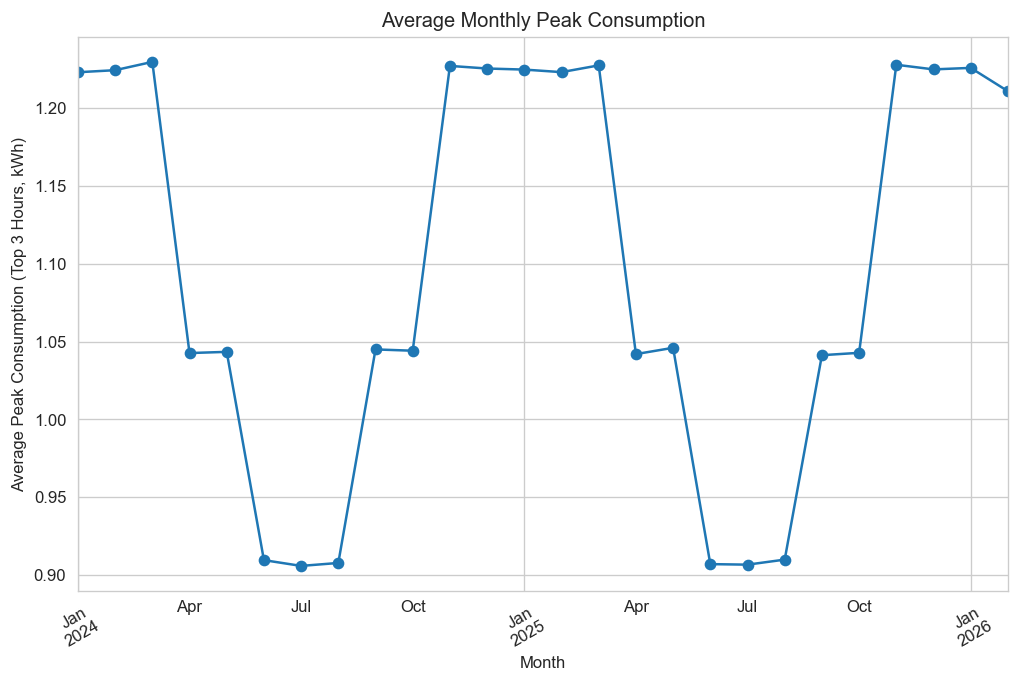

In [28]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    show_legend=False
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

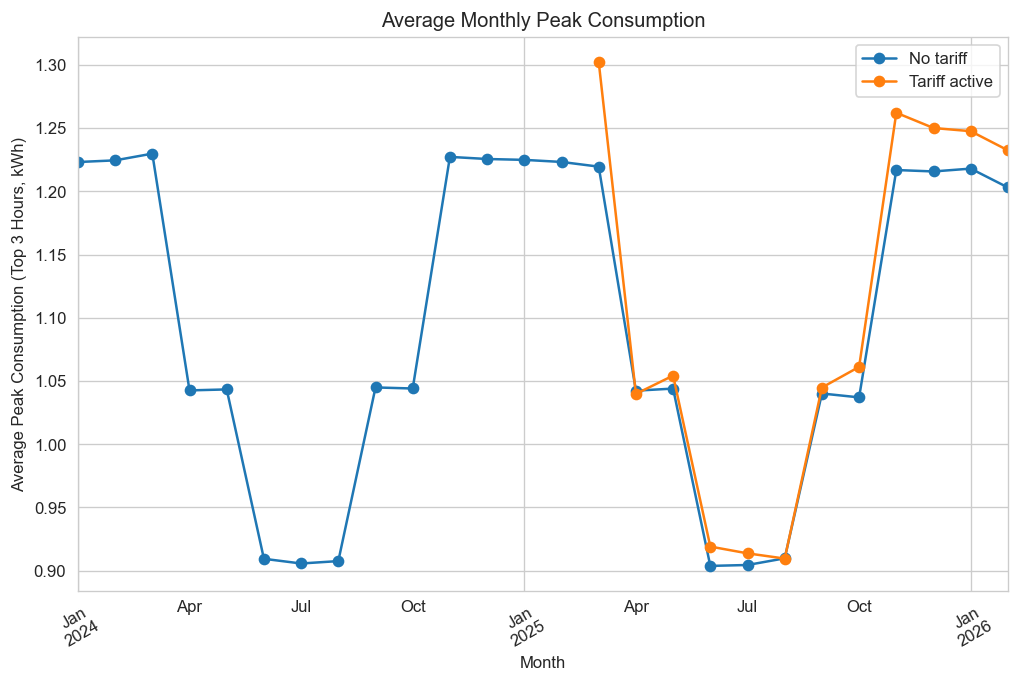

In [29]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
)

Before: 9620
After: 7992


<Axes: title={'center': 'Average Monthly Peak Consumption (Control group: Non-adopters)'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

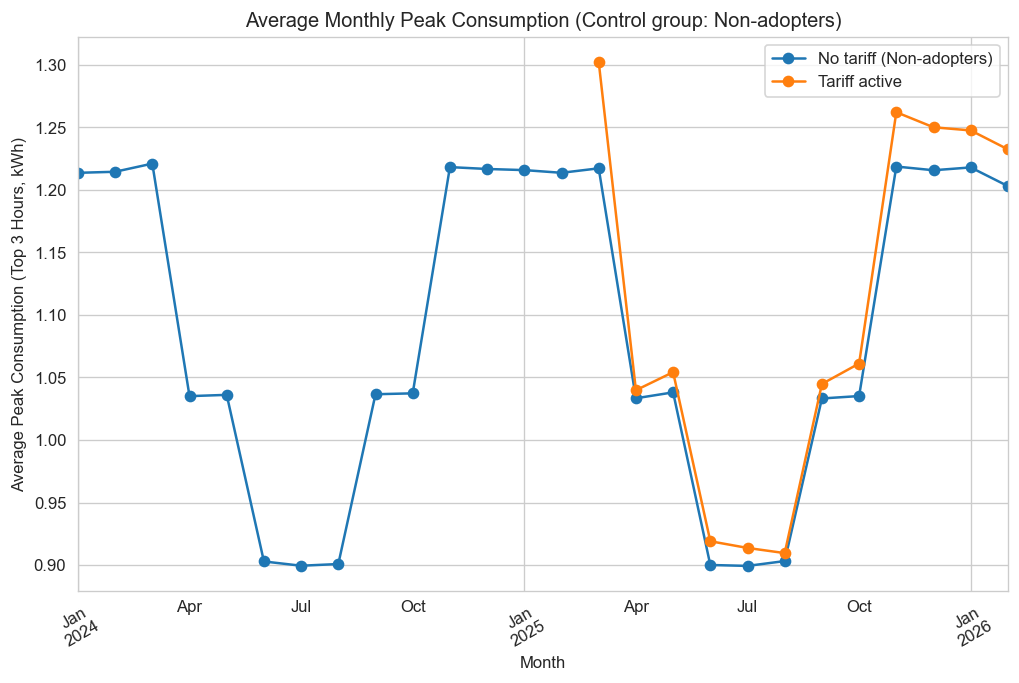

In [30]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

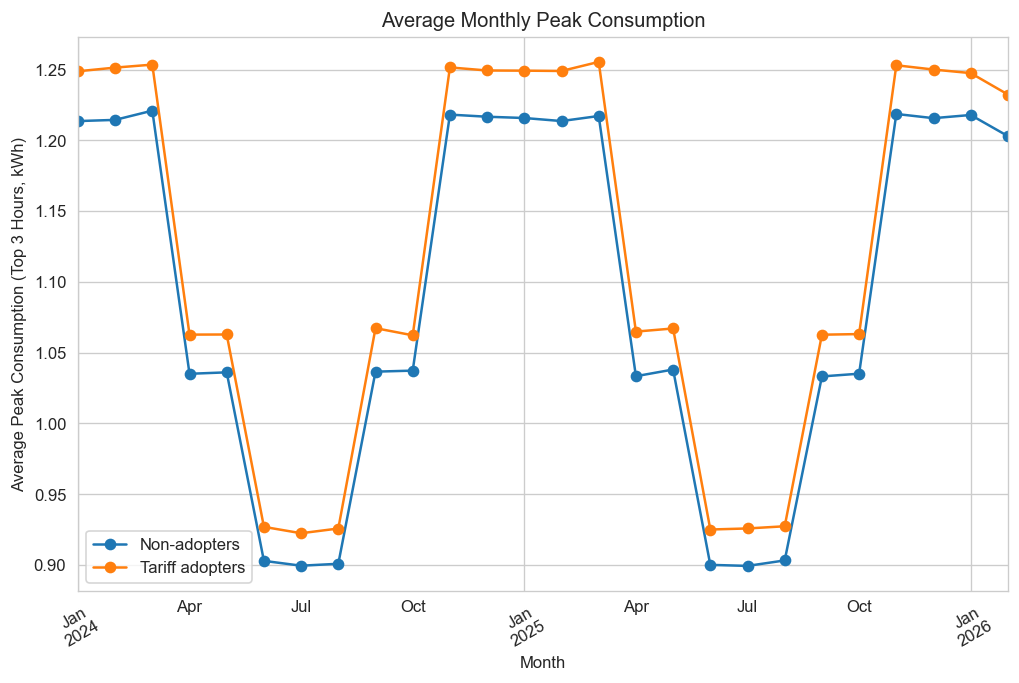

In [31]:
plot_tariff_adoption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption"
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

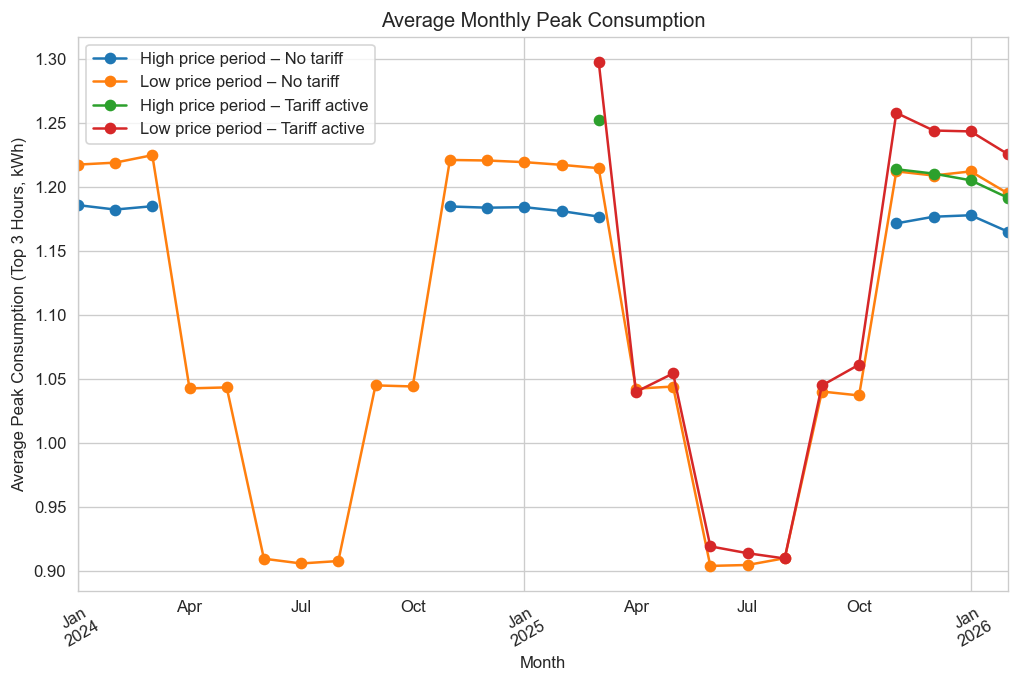

In [32]:
plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"]
)

Before: 23680
After: 19651


<Axes: title={'center': 'Average Monthly Peak Consumption (Control group: Non-adopters)'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

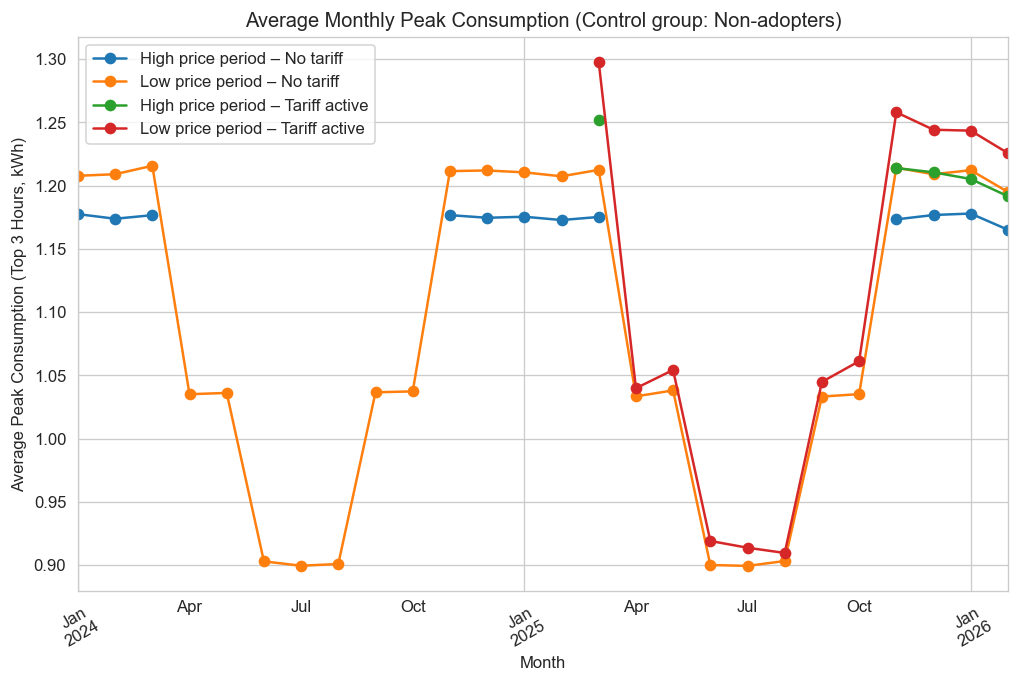

In [33]:
plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"],
    exclude_future_tariff=True
)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

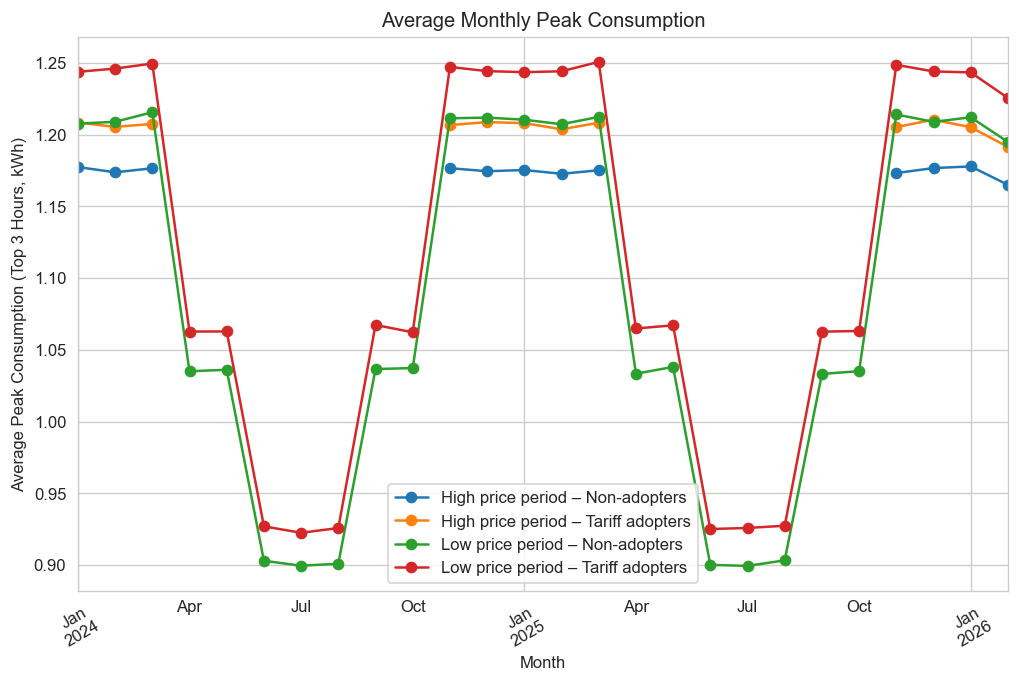

In [34]:
plot_tariff_adoption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    by_price=True
)

In [35]:
# # hour
# plot_consumption(
#     hourly_result,
#     group_by="hour",
#     value_col="mean_consumption",
# )

In [36]:
# # hour
# plot_consumption(
#     hourly_result,
#     group_by="hour",
#     value_col="mean_consumption",
#     splits=["tariff_active"]
# )

In [37]:
# # hour
# plot_consumption(
#     hourly_result,
#     group_by="hour",
#     value_col="mean_consumption",
#     splits=["tariff_active"],
#     exclude_future_tariff=True
# )

In [38]:
# plot_tariff_adoption(
#     hourly_result,
#     group_by="hour",
#     value_col="mean_consumption",
# )

In [39]:
# # weekend, week
# plot_consumption(
#     weekly_result,
#     group_by="weekday",
#     value_col="mean_consumption",
# )

In [40]:
# plot_consumption(
#     weekly_result,
#     group_by="week",
#     value_col="mean_consumption",
#     splits=["tariff_active"],
# )

In [41]:
# # week
# plot_consumption(
#     weekly_result,
#     group_by="week",
#     value_col="mean_consumption",
#     splits=["tariff_active"],
#     exclude_future_tariff=True
# )

In [42]:
# plot_tariff_adoption(
#     weekly_result,
#     group_by="week",
#     value_col="mean_consumption",
# )

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

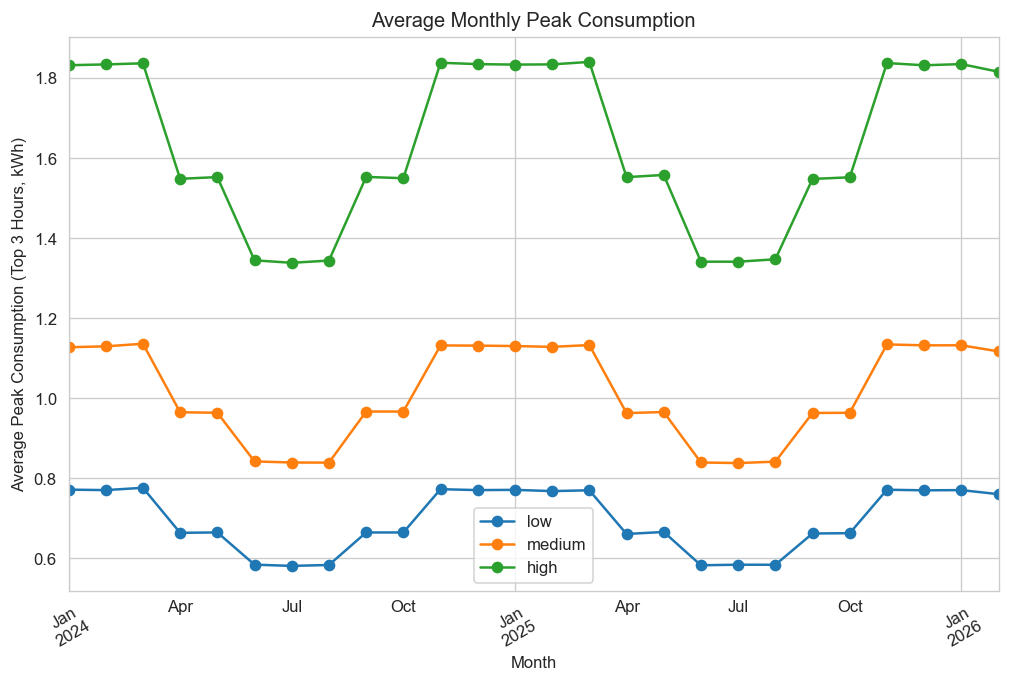

In [43]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group"]
)

array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

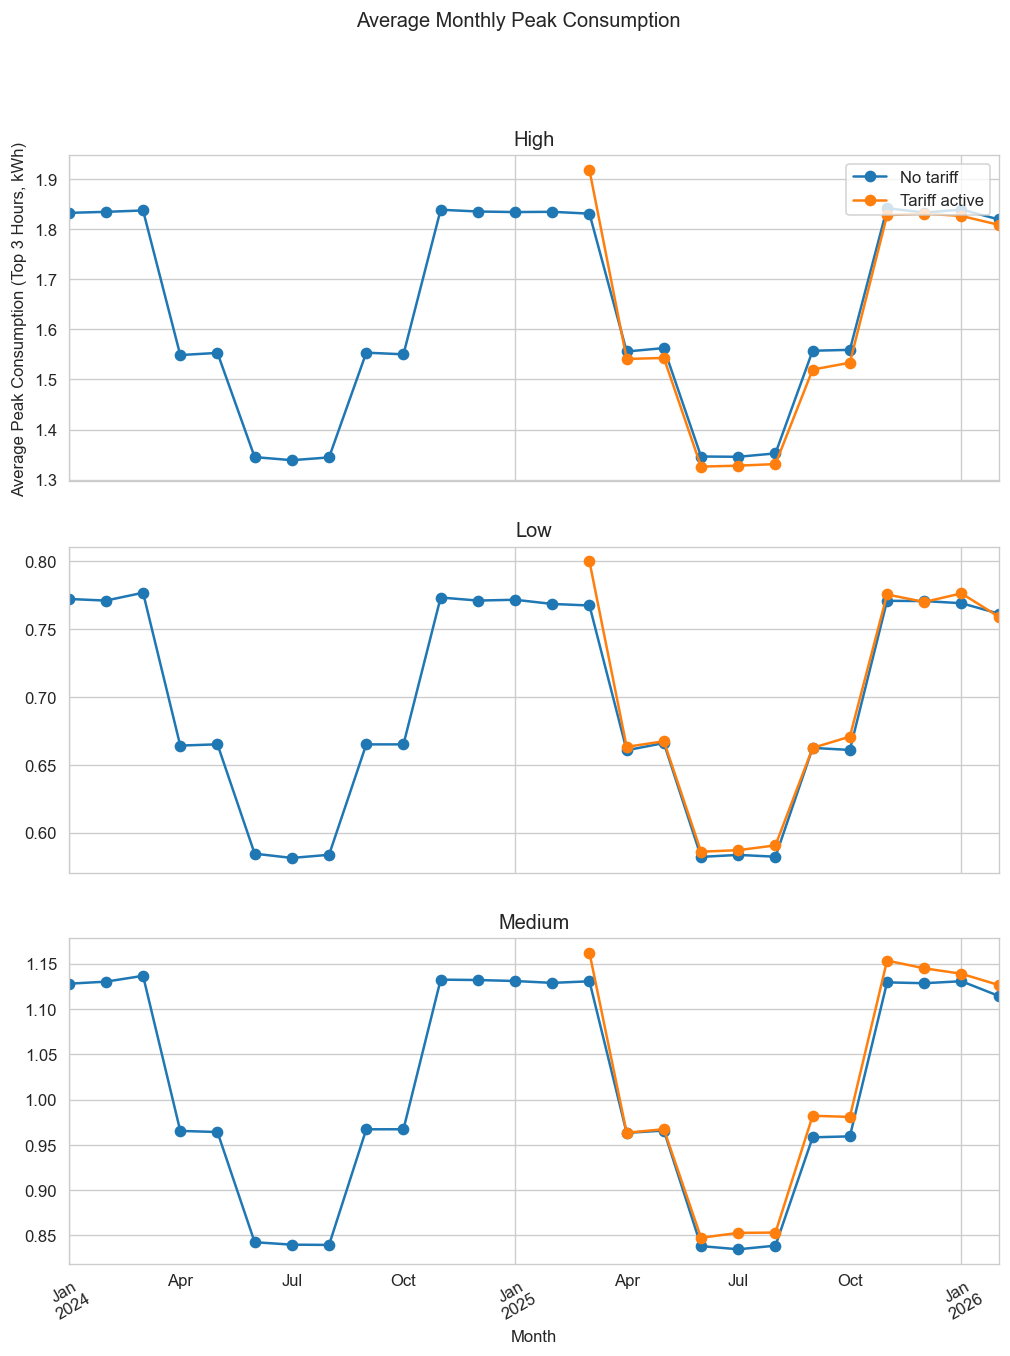

In [44]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    facet_by="usage_group"
)

Before: 9620
After: 7992


array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

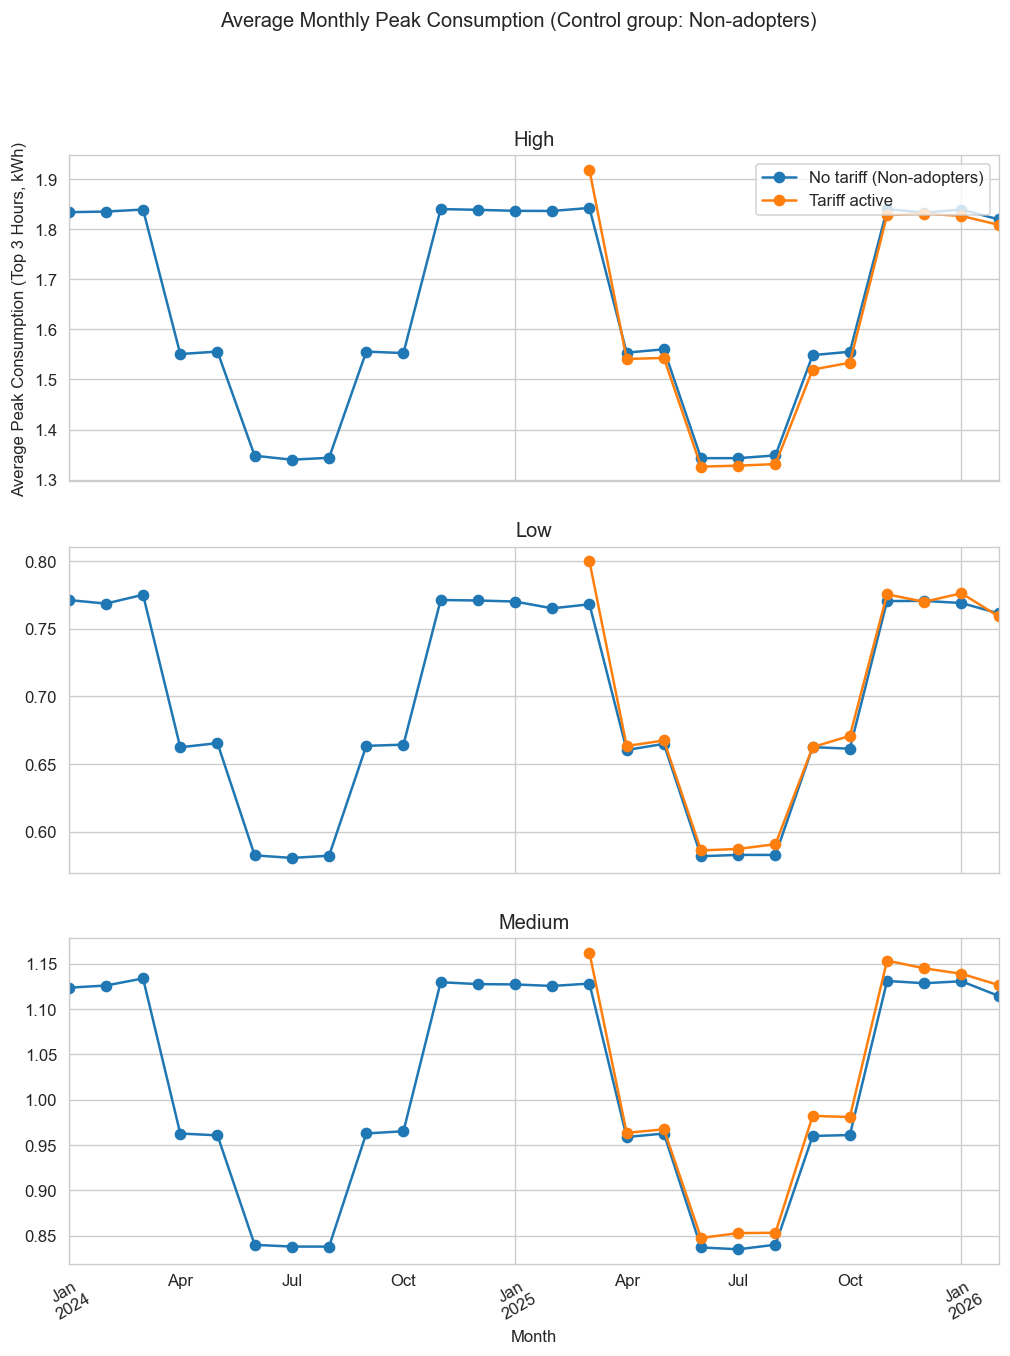

In [45]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    exclude_future_tariff=True,
    facet_by="usage_group"
)

<Axes: title={'center': 'Tariff Adoption by Household Usage Group'}, xlabel='Household Usage Group', ylabel='Share Choosing Tariff'>

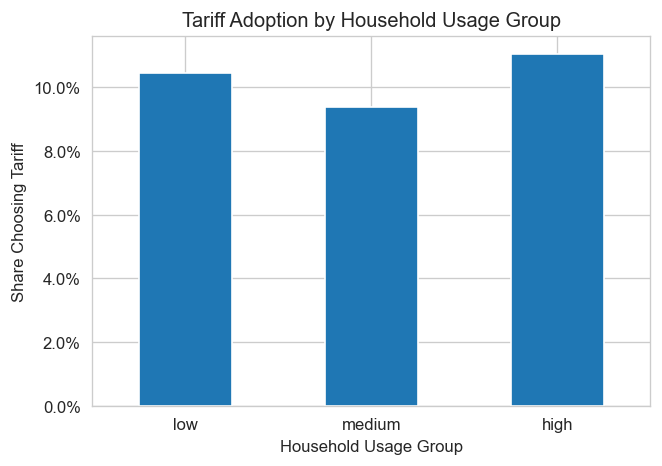

In [46]:
# plot_tariff_adoption_by_usage(
#     month_result[month_result["price"] == "all"],
#     figsize=(6, 4)
# )

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

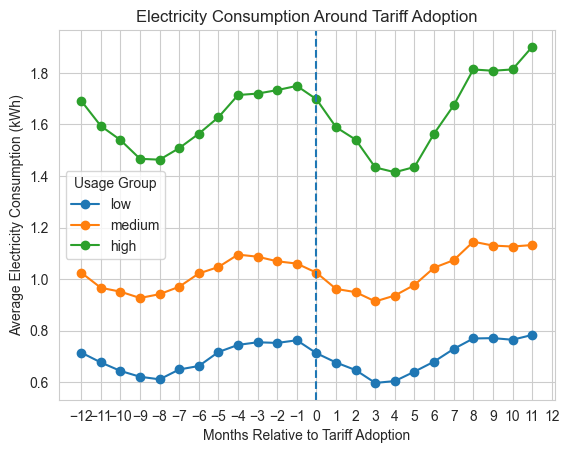

In [47]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

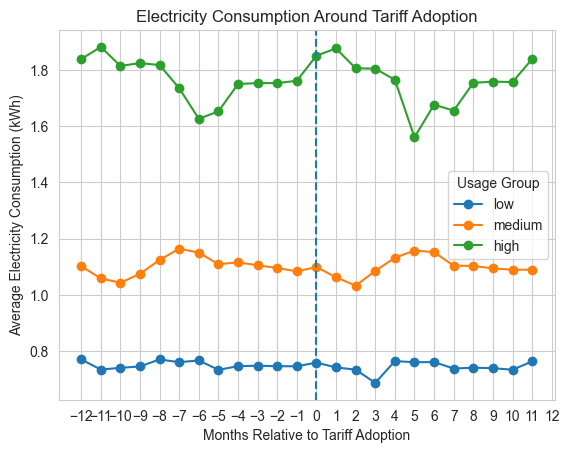

In [48]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

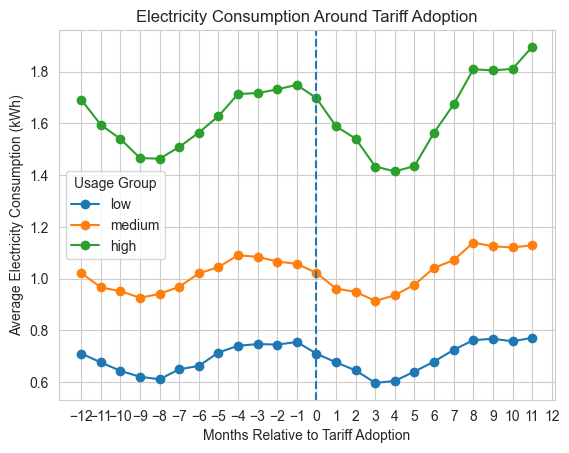

In [49]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

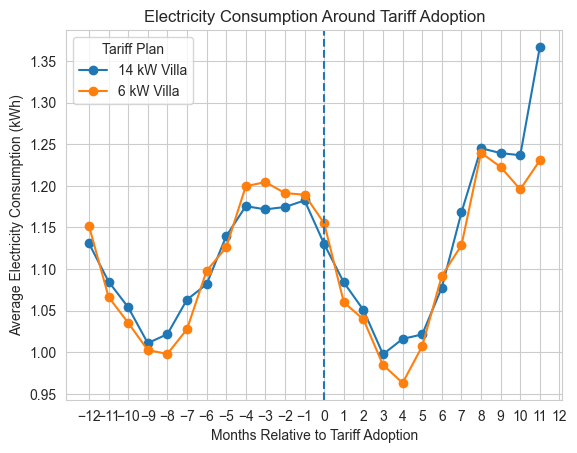

In [50]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

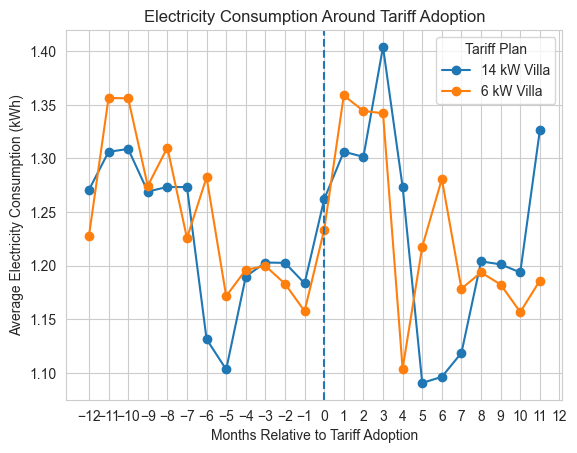

In [51]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

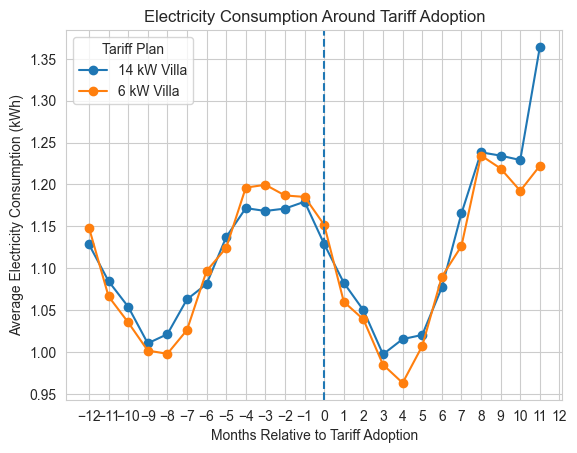

In [52]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

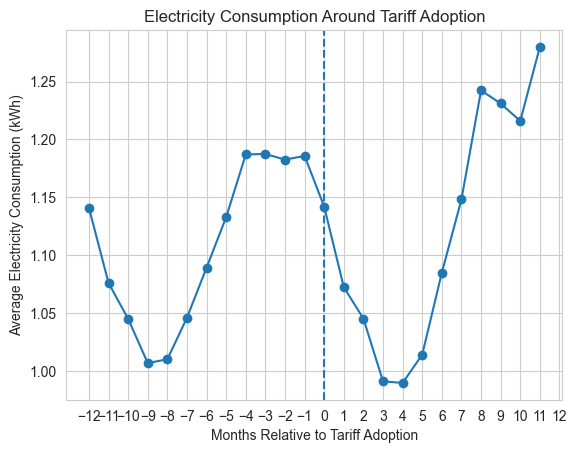

In [53]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

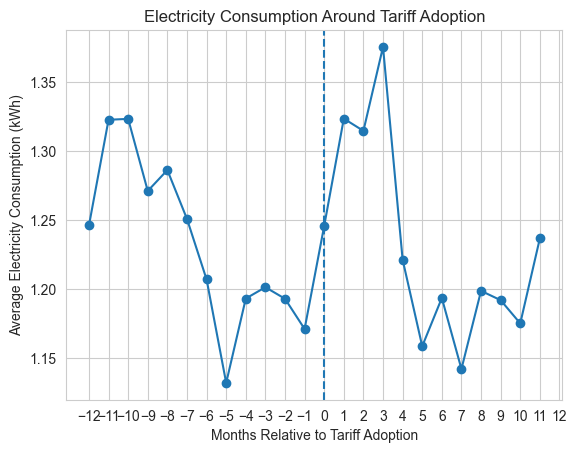

In [54]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    window=12
)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

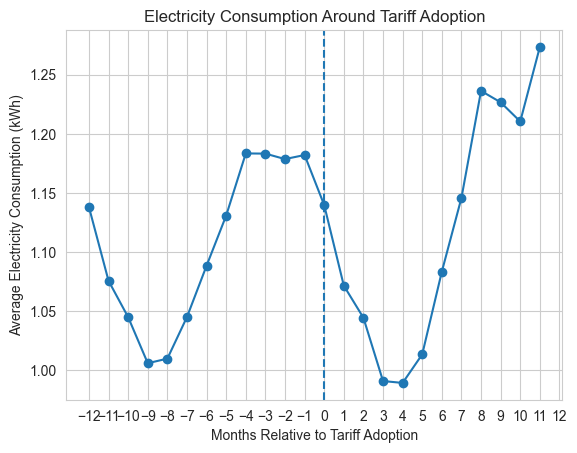

In [55]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    window=12
)

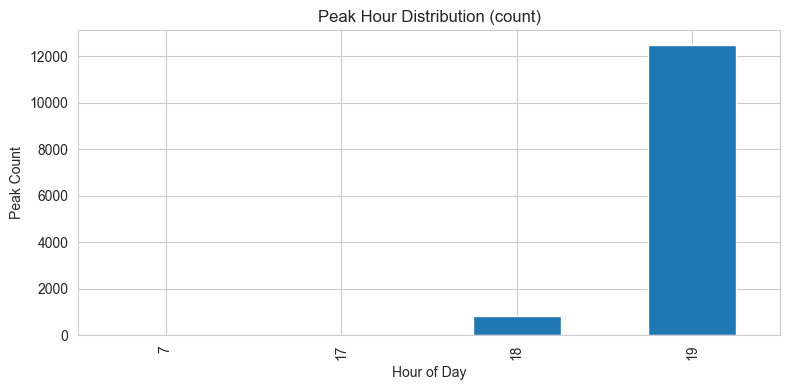

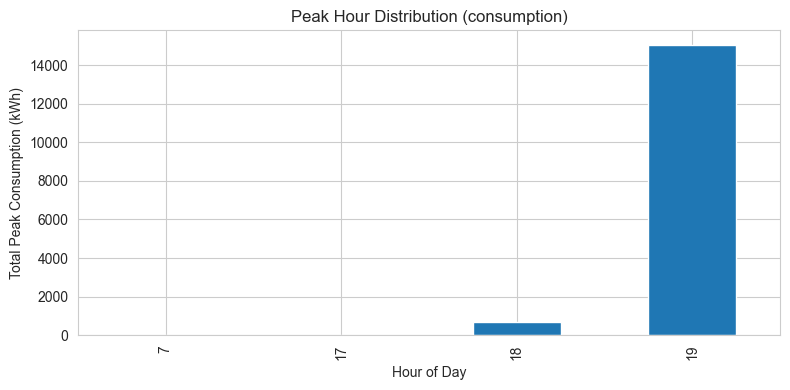

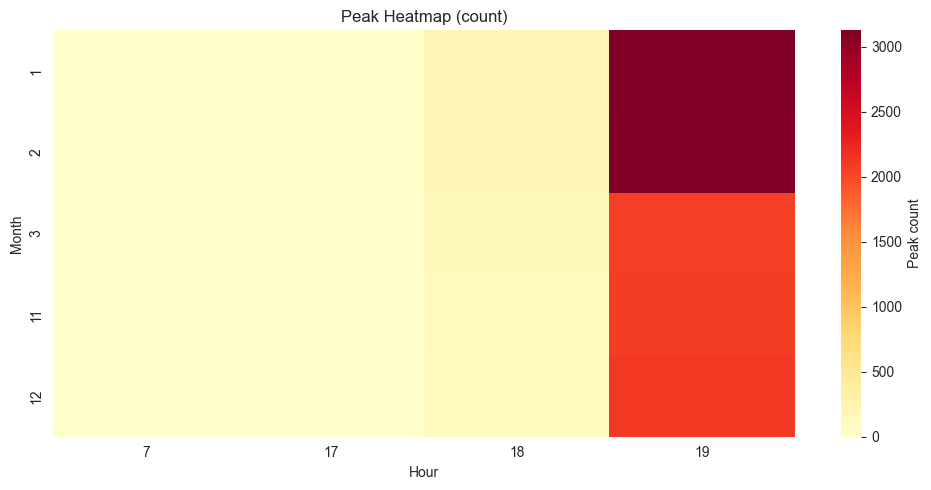

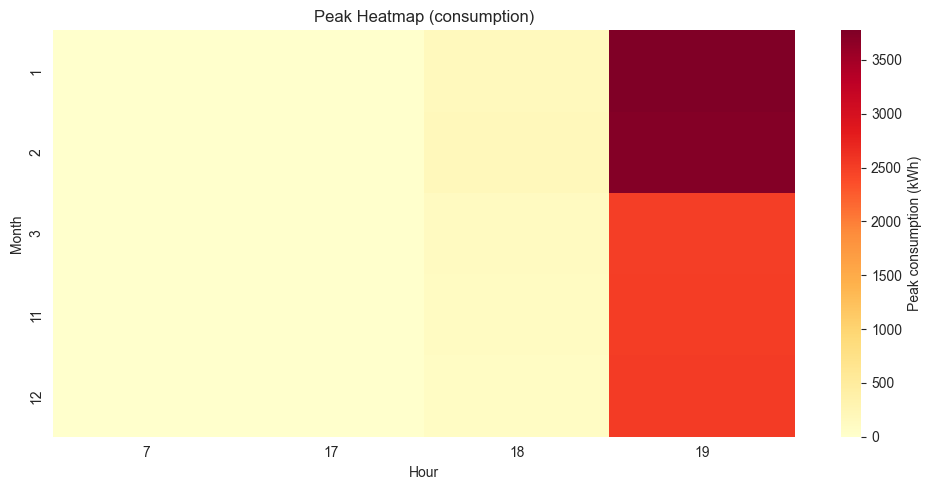

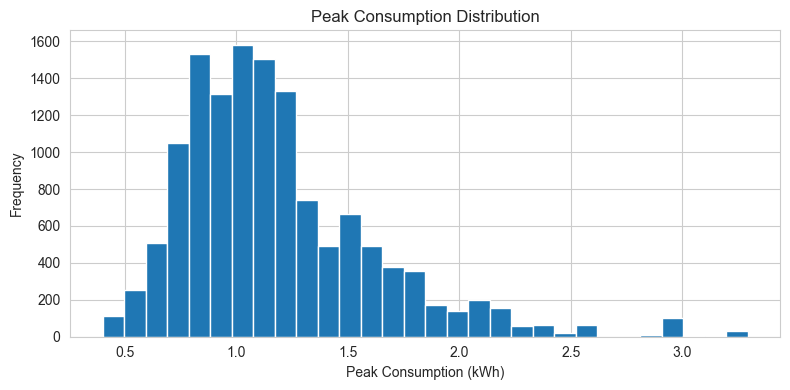

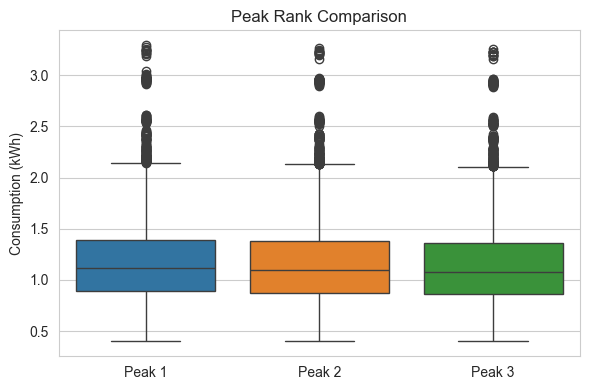

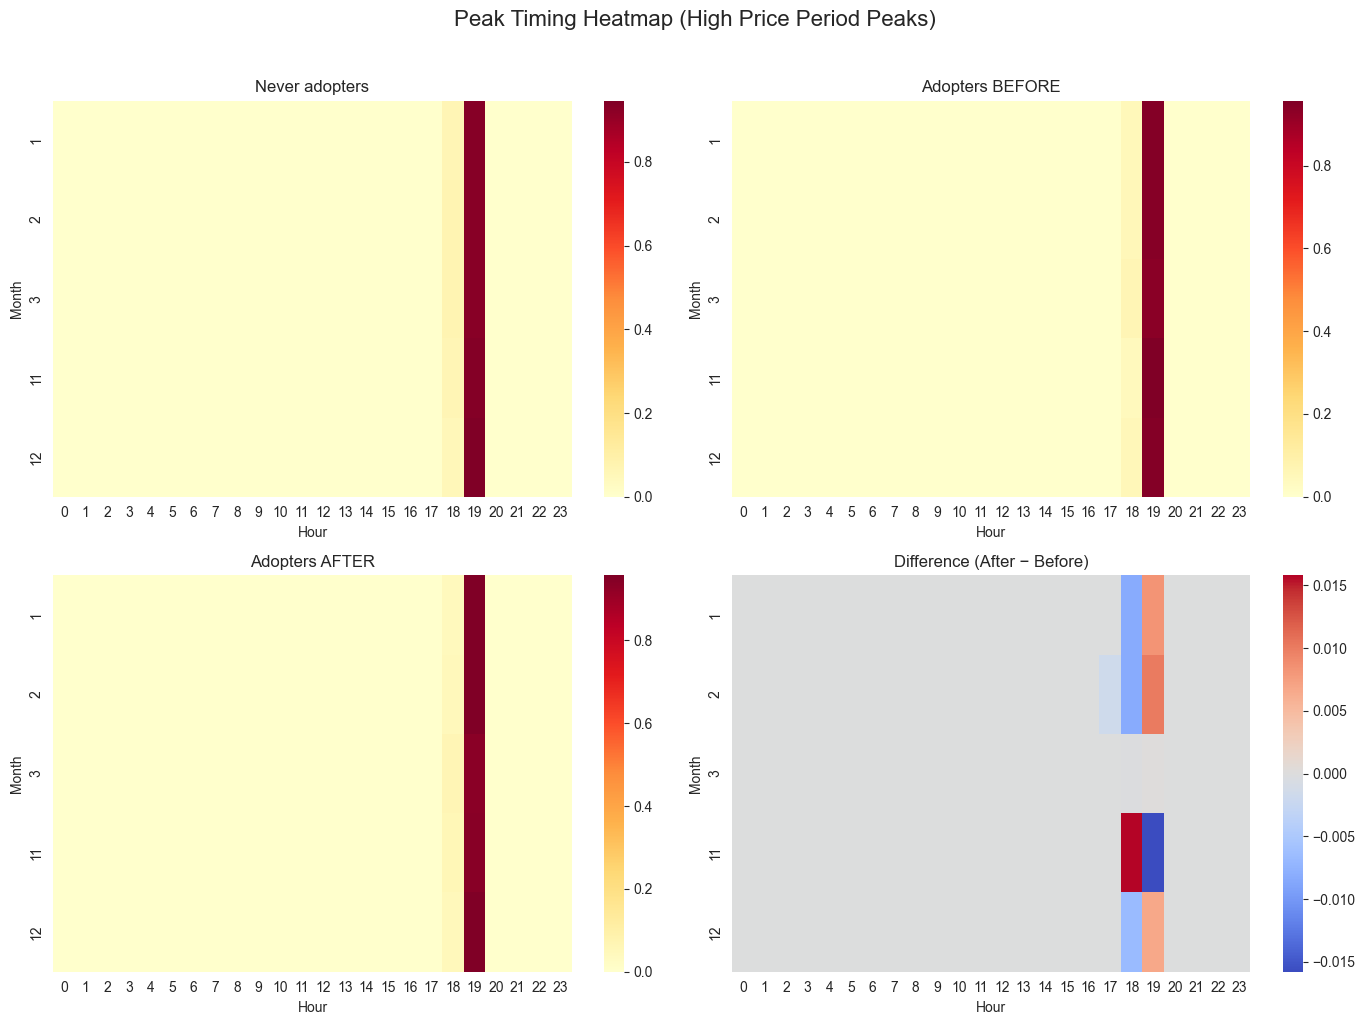

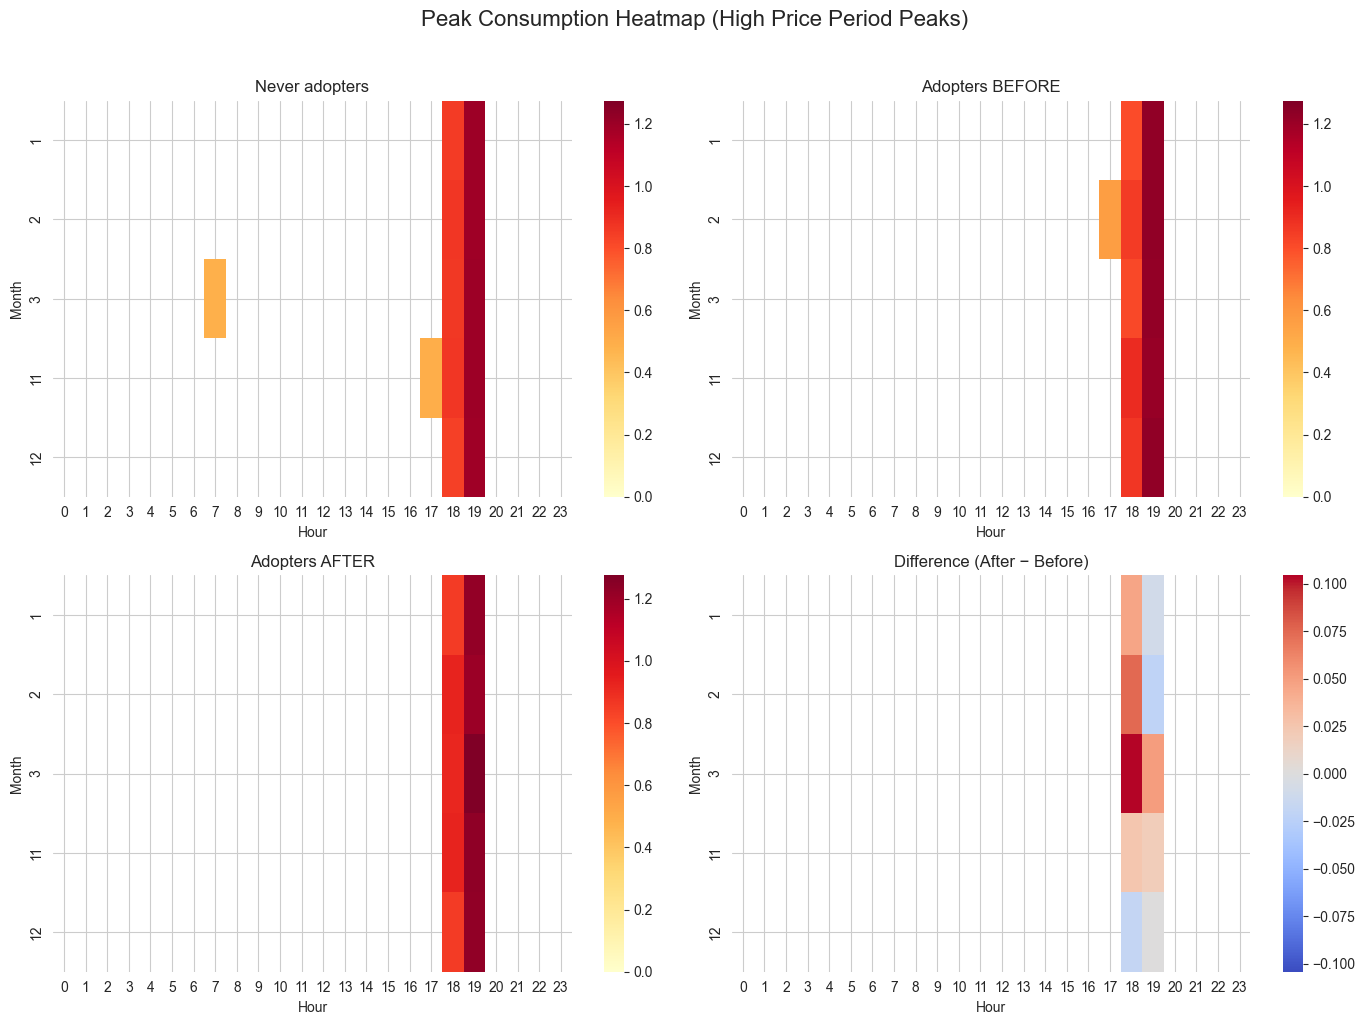

In [56]:
# Peak hour distribution (count)
# 看 peak 最常發生在一天的哪個小時
pp.plot_peak_hour_distribution(month_result[month_result["price"] == "high"])

# Peak hour distribution (consumption)
# 看哪個小時的 peak 用電量總和最高（電網壓力）
pp.plot_peak_hour_distribution(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak heatmap (count)
# Month × Hour heatmap，看不同月份 peak 最常出現的時間
pp.plot_peak_heatmap(month_result[month_result["price"] == "high"])

# Peak heatmap (consumption)
# Month × Hour heatmap，但用顏色表示 peak 用電量
pp.plot_peak_heatmap(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak consumption distribution
# Histogram，看 peak demand 的大小分布（household peak size）
pp.plot_peak_consumption_distribution(
    month_result[month_result["price"] == "high"]
)

# Peak rank boxplot
# 比較 peak1 / peak2 / peak3 的用電量分布，看 spike 程度
pp.plot_peak_rank_boxplot(
    month_result[month_result["price"] == "high"]
)

# Peak timing heatmap: P(hour | peak)
# 比較 tariff 前後 peak 發生次數的 Month × Hour heatmap
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

# # Peak consumption heatmap: E(consumption | peak hour)
pp.plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

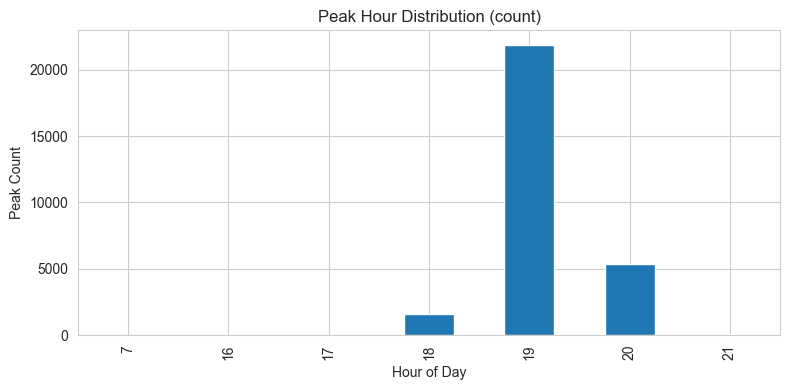

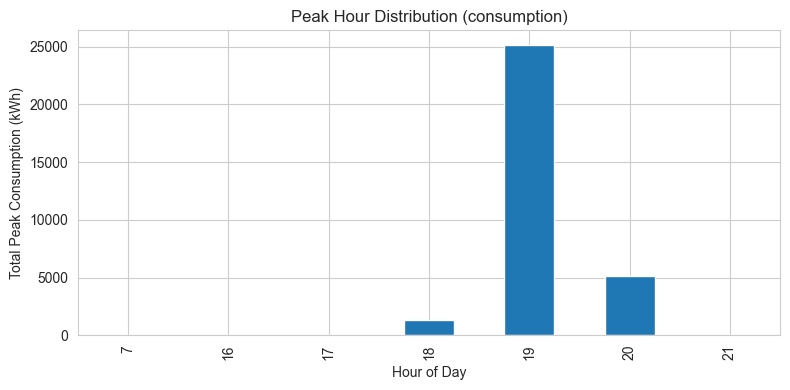

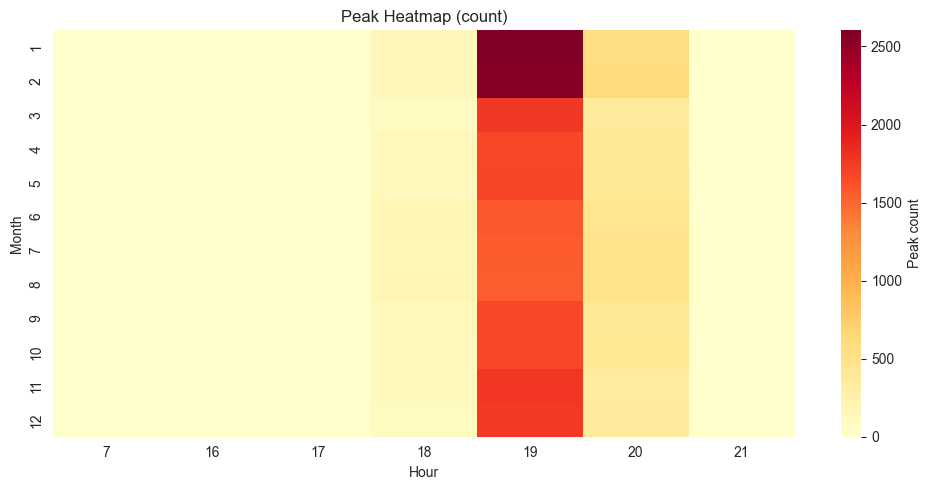

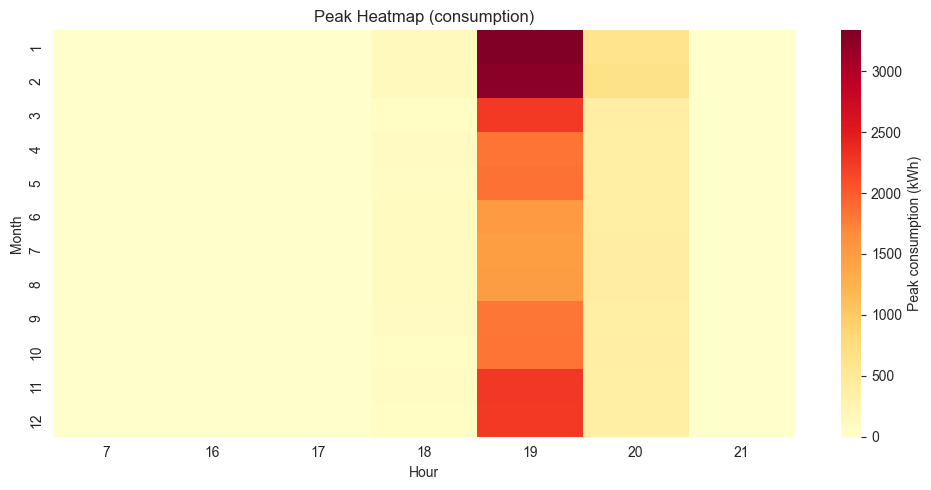

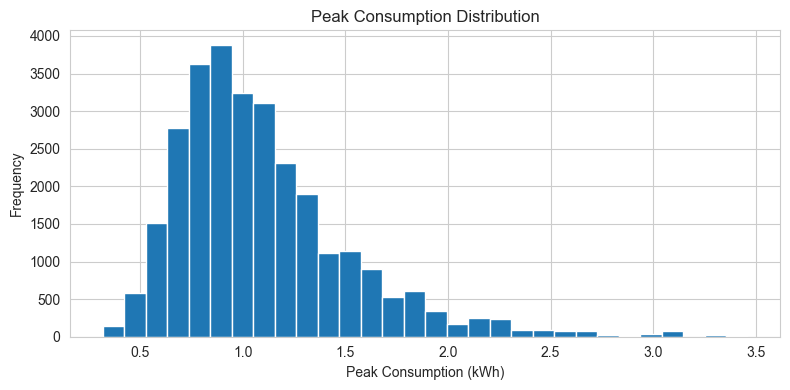

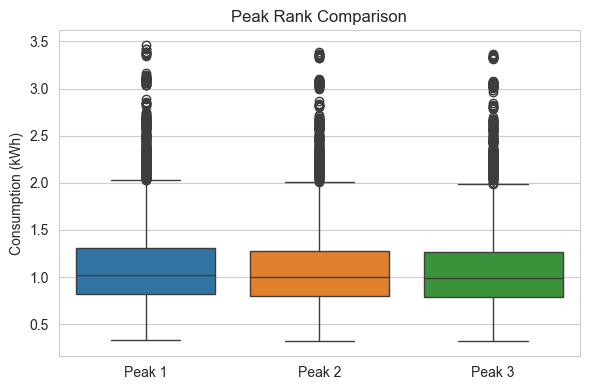

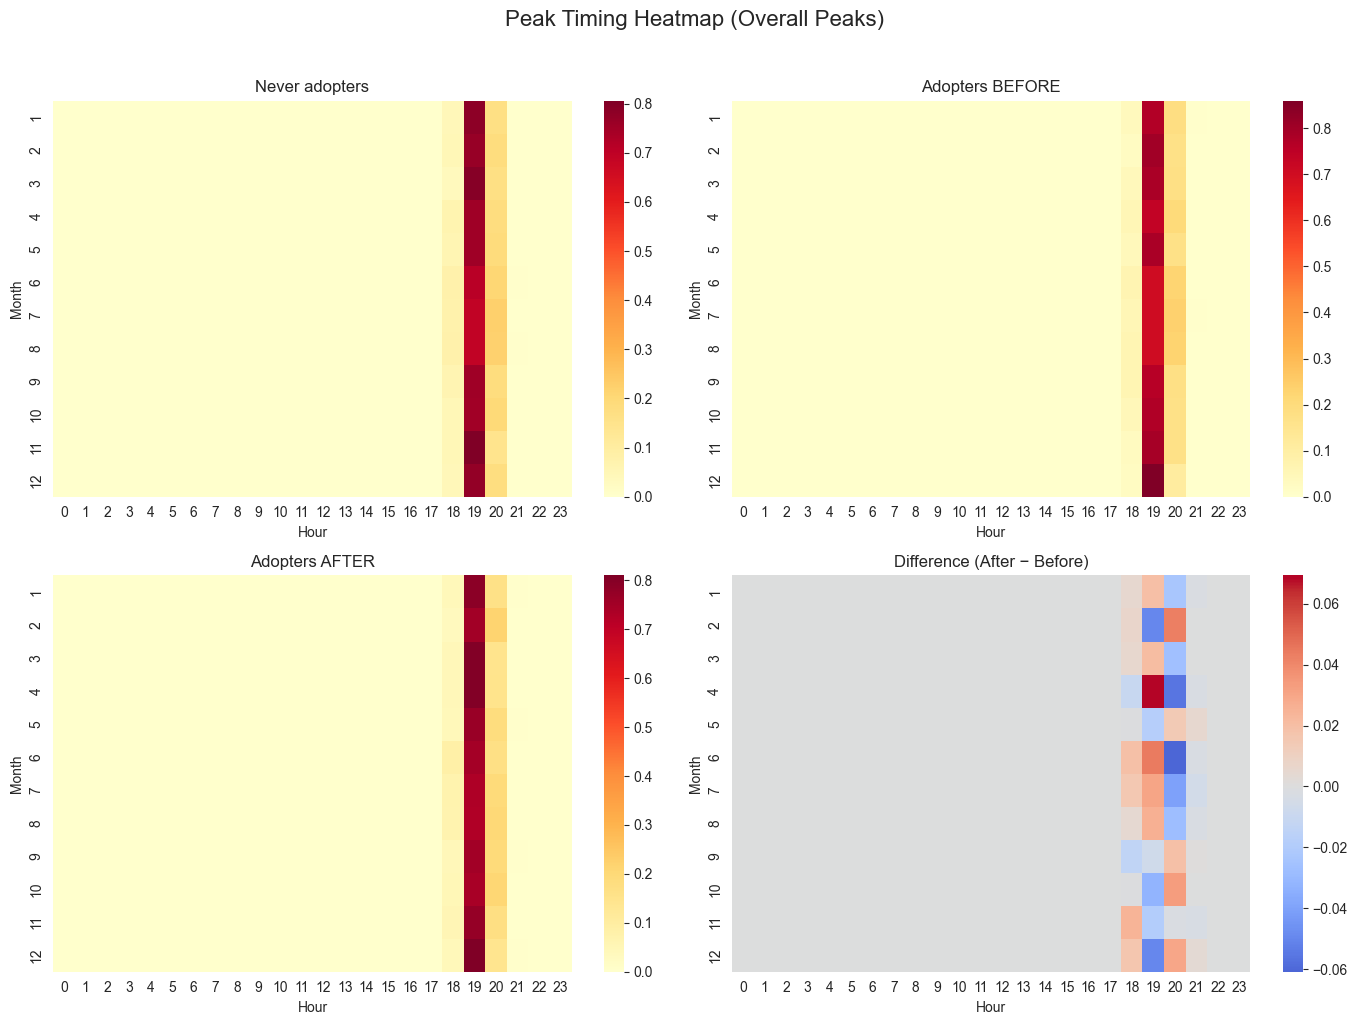

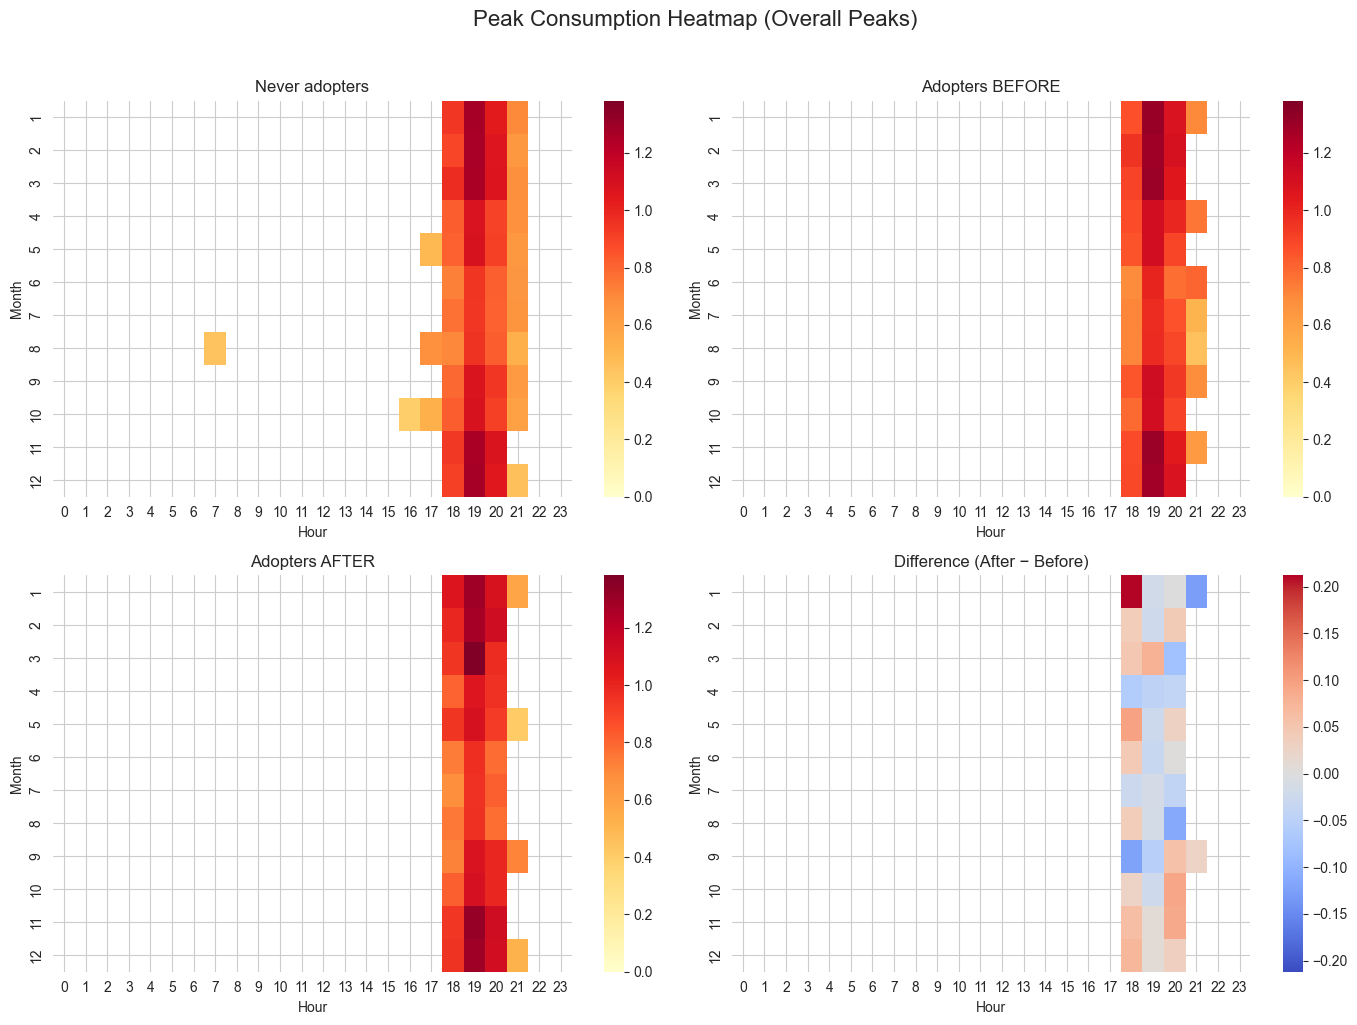

In [57]:
# Overall peak analysis
# Peak hour distribution (count)
pp.plot_peak_hour_distribution(month_result[month_result["price"] == "all"])

# Peak hour distribution (consumption)
pp.plot_peak_hour_distribution(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak heatmap (count)
pp.plot_peak_heatmap(month_result[month_result["price"] == "all"])

# Peak heatmap (consumption)
pp.plot_peak_heatmap(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak consumption distribution
pp.plot_peak_consumption_distribution(
    month_result[month_result["price"] == "all"]
)

# Peak rank boxplot
pp.plot_peak_rank_boxplot(
    month_result[month_result["price"] == "all"]
)

# Peak timing heatmap: P(hour | peak)
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "all"], 
    price_label="all"
)

# # Peak consumption heatmap: E(consumption | peak hour)
pp.plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "all"],
    price_label="all"
)


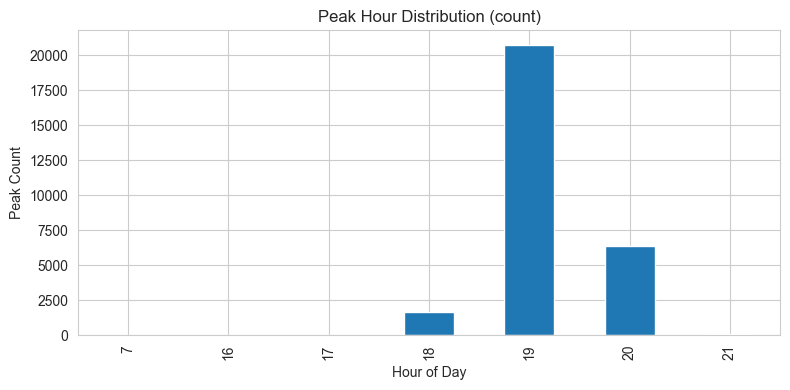

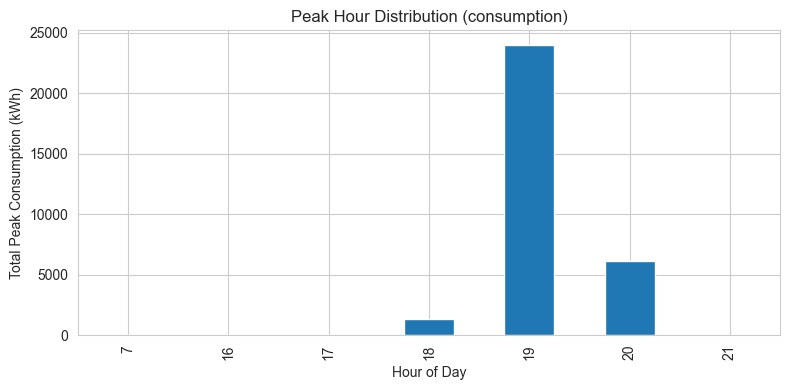

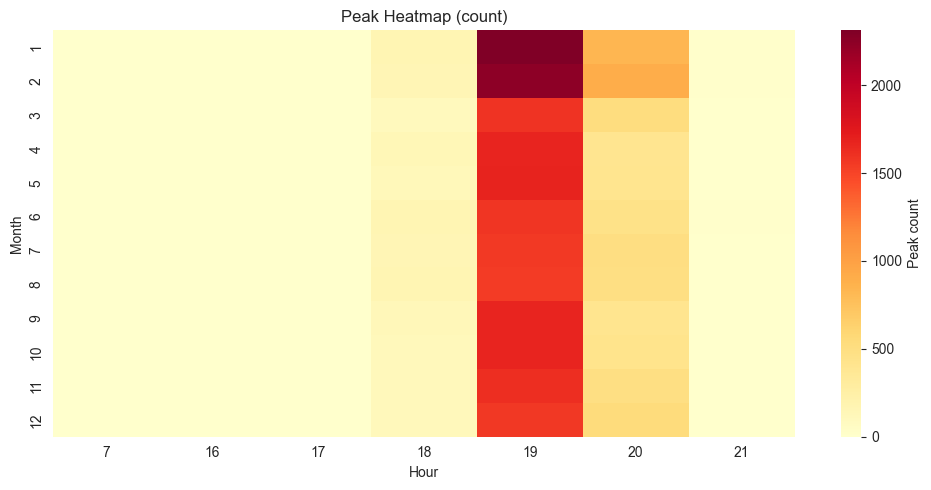

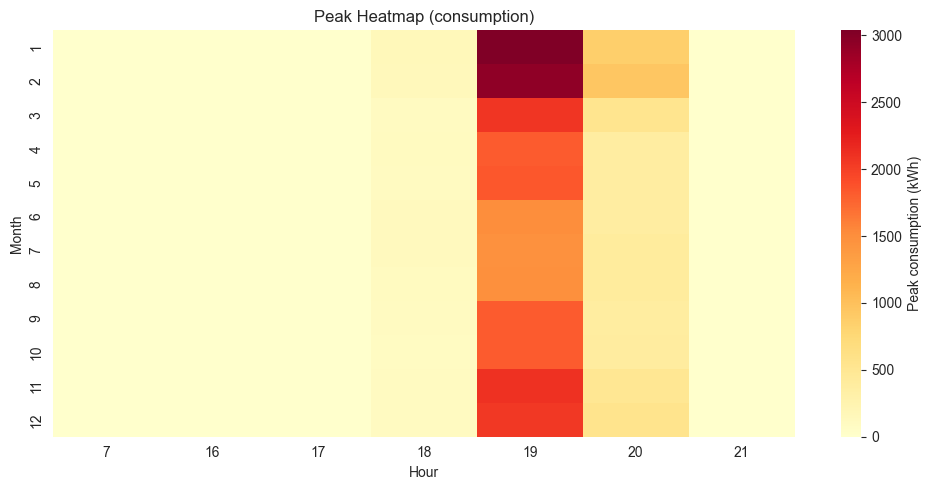

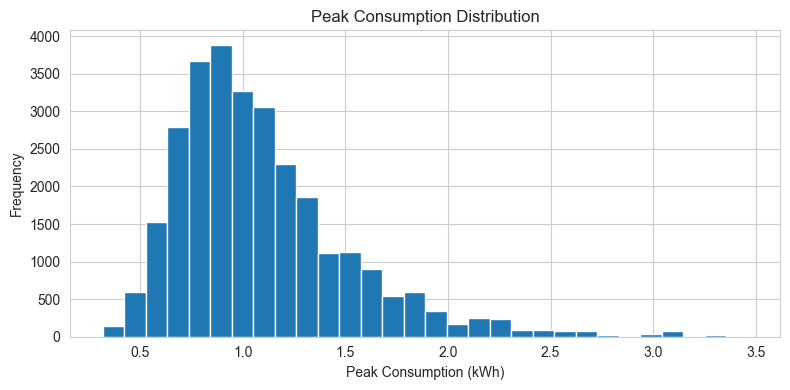

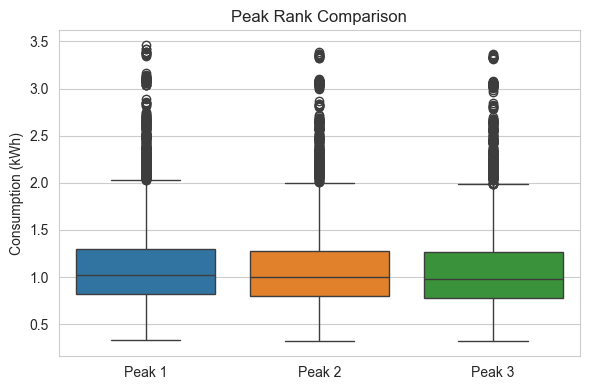

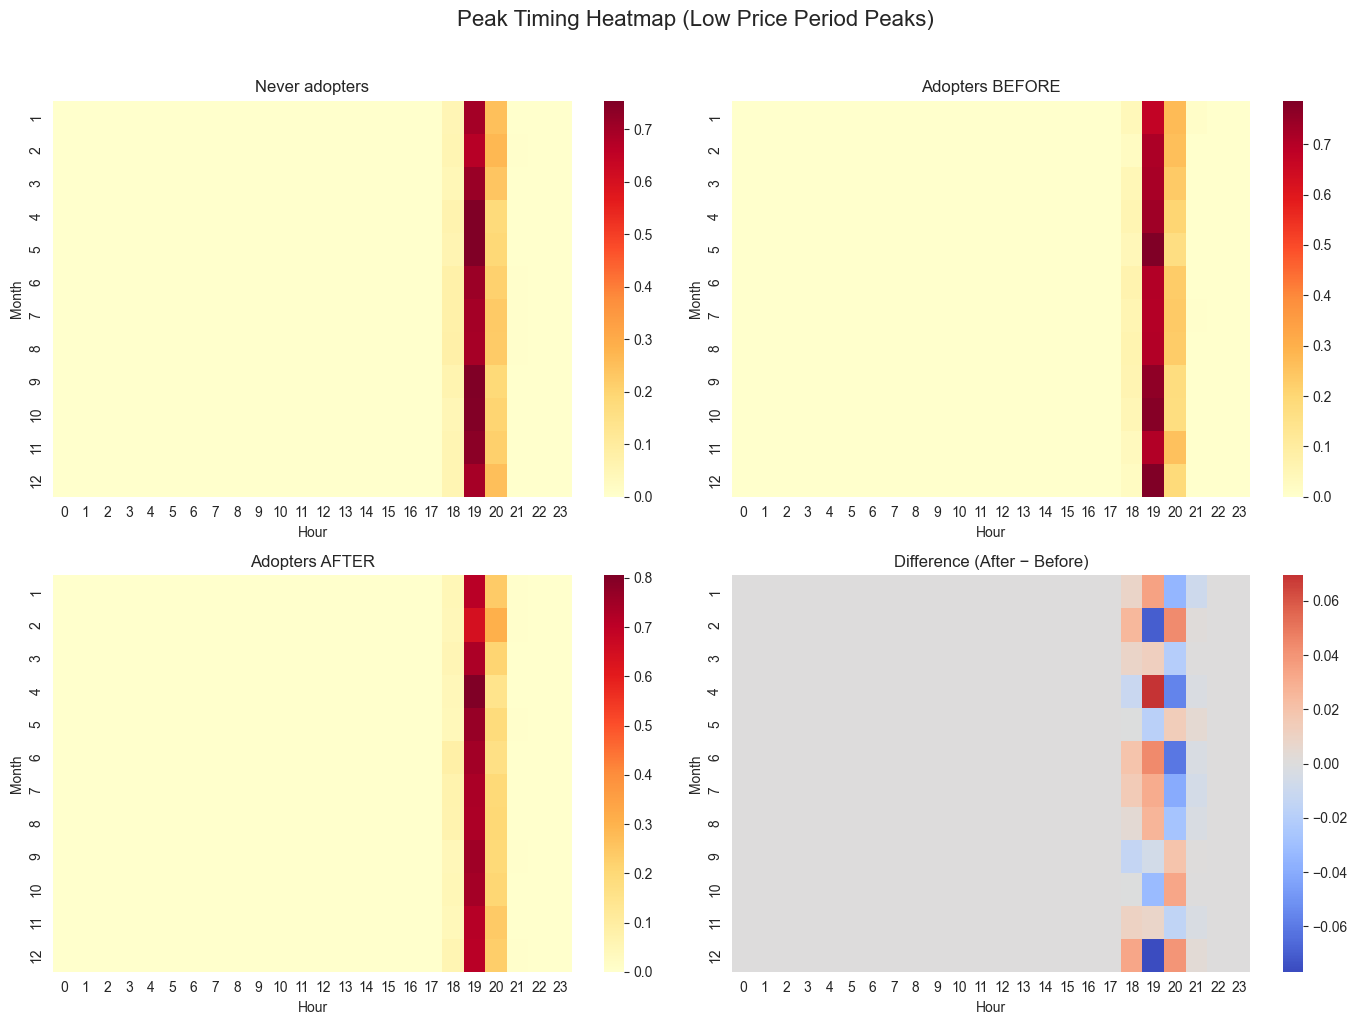

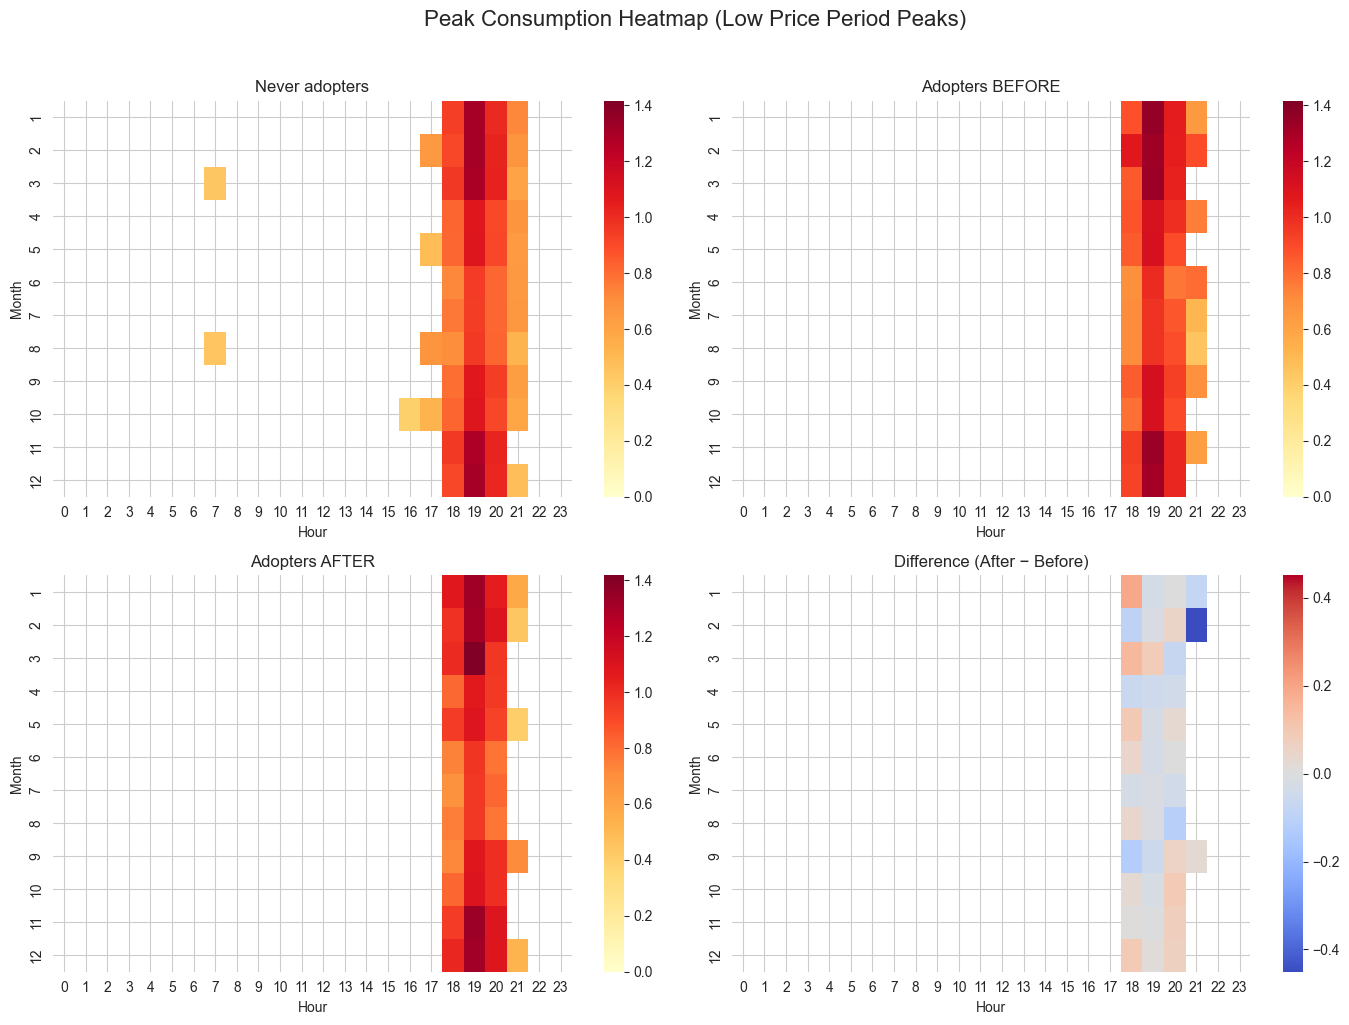

In [58]:
# Low peak analysis
# Peak hour distribution (count)
pp.plot_peak_hour_distribution(month_result[month_result["price"] == "low"])

# Peak hour distribution (consumption)
pp.plot_peak_hour_distribution(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak heatmap (count)
pp.plot_peak_heatmap(month_result[month_result["price"] == "low"])

# Peak heatmap (consumption)
pp.plot_peak_heatmap(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak consumption distribution
pp.plot_peak_consumption_distribution(
    month_result[month_result["price"] == "low"]
)

# Peak rank boxplot
pp.plot_peak_rank_boxplot(
    month_result[month_result["price"] == "low"]
)

# Peak timing heatmap: P(hour | peak)
pp.plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


# # Peak consumption heatmap: E(consumption | peak hour)
pp.plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


## Look at specific month

In [59]:
# plot_cohort_calendar(
#     month_result[month_result["price"] == "all"],
#     cohort_month="2025-03"
# )
# plot_cohort_calendar(
#     month_result[month_result["price"] == "all"],
#     cohort_month="2025-04"
# )

<Axes: title={'center': 'Average Peak Consumption by Tariff Adoption Month'}, xlabel='Month', ylabel='Average Consumption (kWh)'>

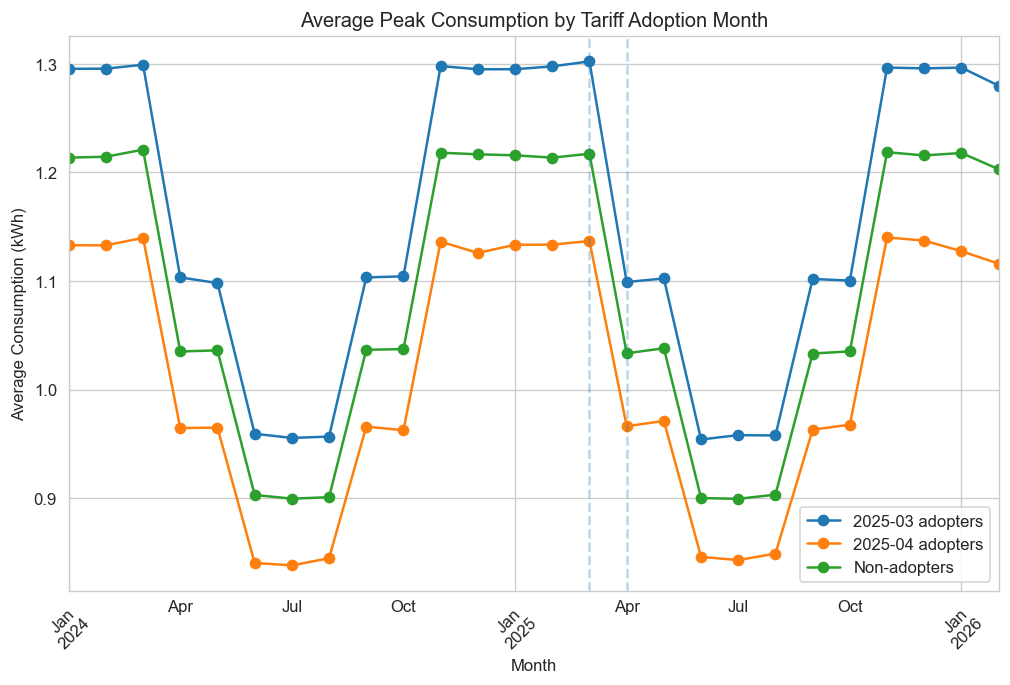

In [60]:
plot_multiple_cohorts(
    month_result[month_result["price"] == "all"],
    cohort_months=["2025-03", "2025-04", ]
)

<Axes: title={'center': 'Average Peak Consumption by Tariff Adoption Month'}, xlabel='Month', ylabel='Average Consumption (kWh)'>

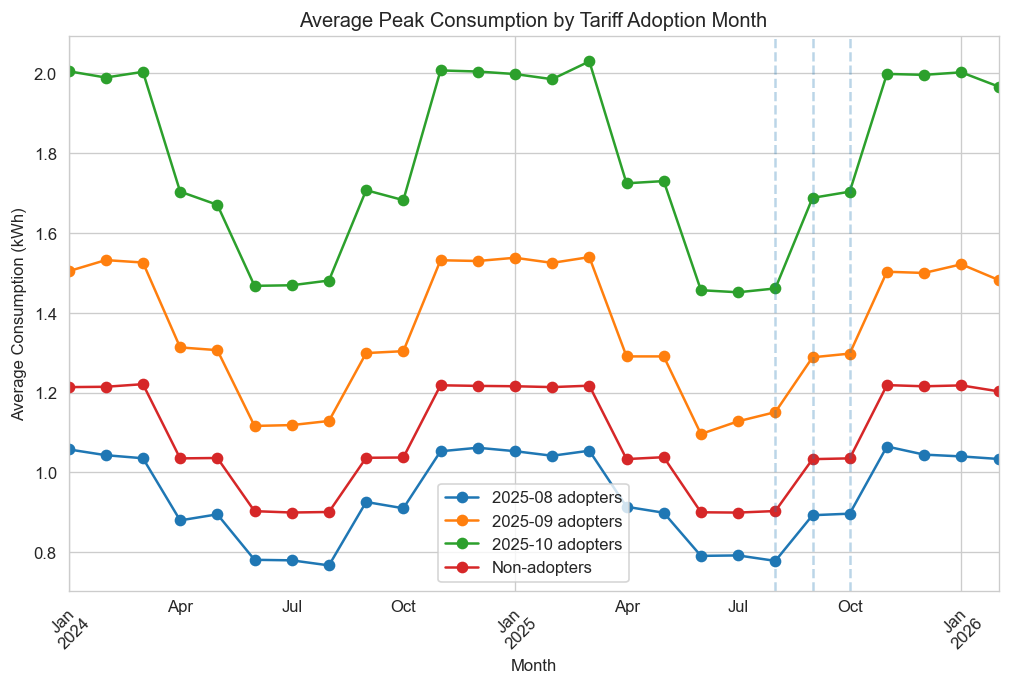

In [61]:
plot_multiple_cohorts(
    month_result[month_result["price"] == "all"],
    cohort_months=["2025-08", "2025-09", "2025-10"]
)

array([<Axes: title={'center': 'Mar 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Apr 2025 adopters'}>,
       <Axes: title={'center': 'May 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Jun 2025 adopters'}>,
       <Axes: title={'center': 'Jul 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Aug 2025 adopters'}>,
       <Axes: title={'center': 'Sep 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Oct 2025 adopters'}>,
       <Axes: title={'center': 'Nov 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Dec 2025 adopters'}>], dtype=object)

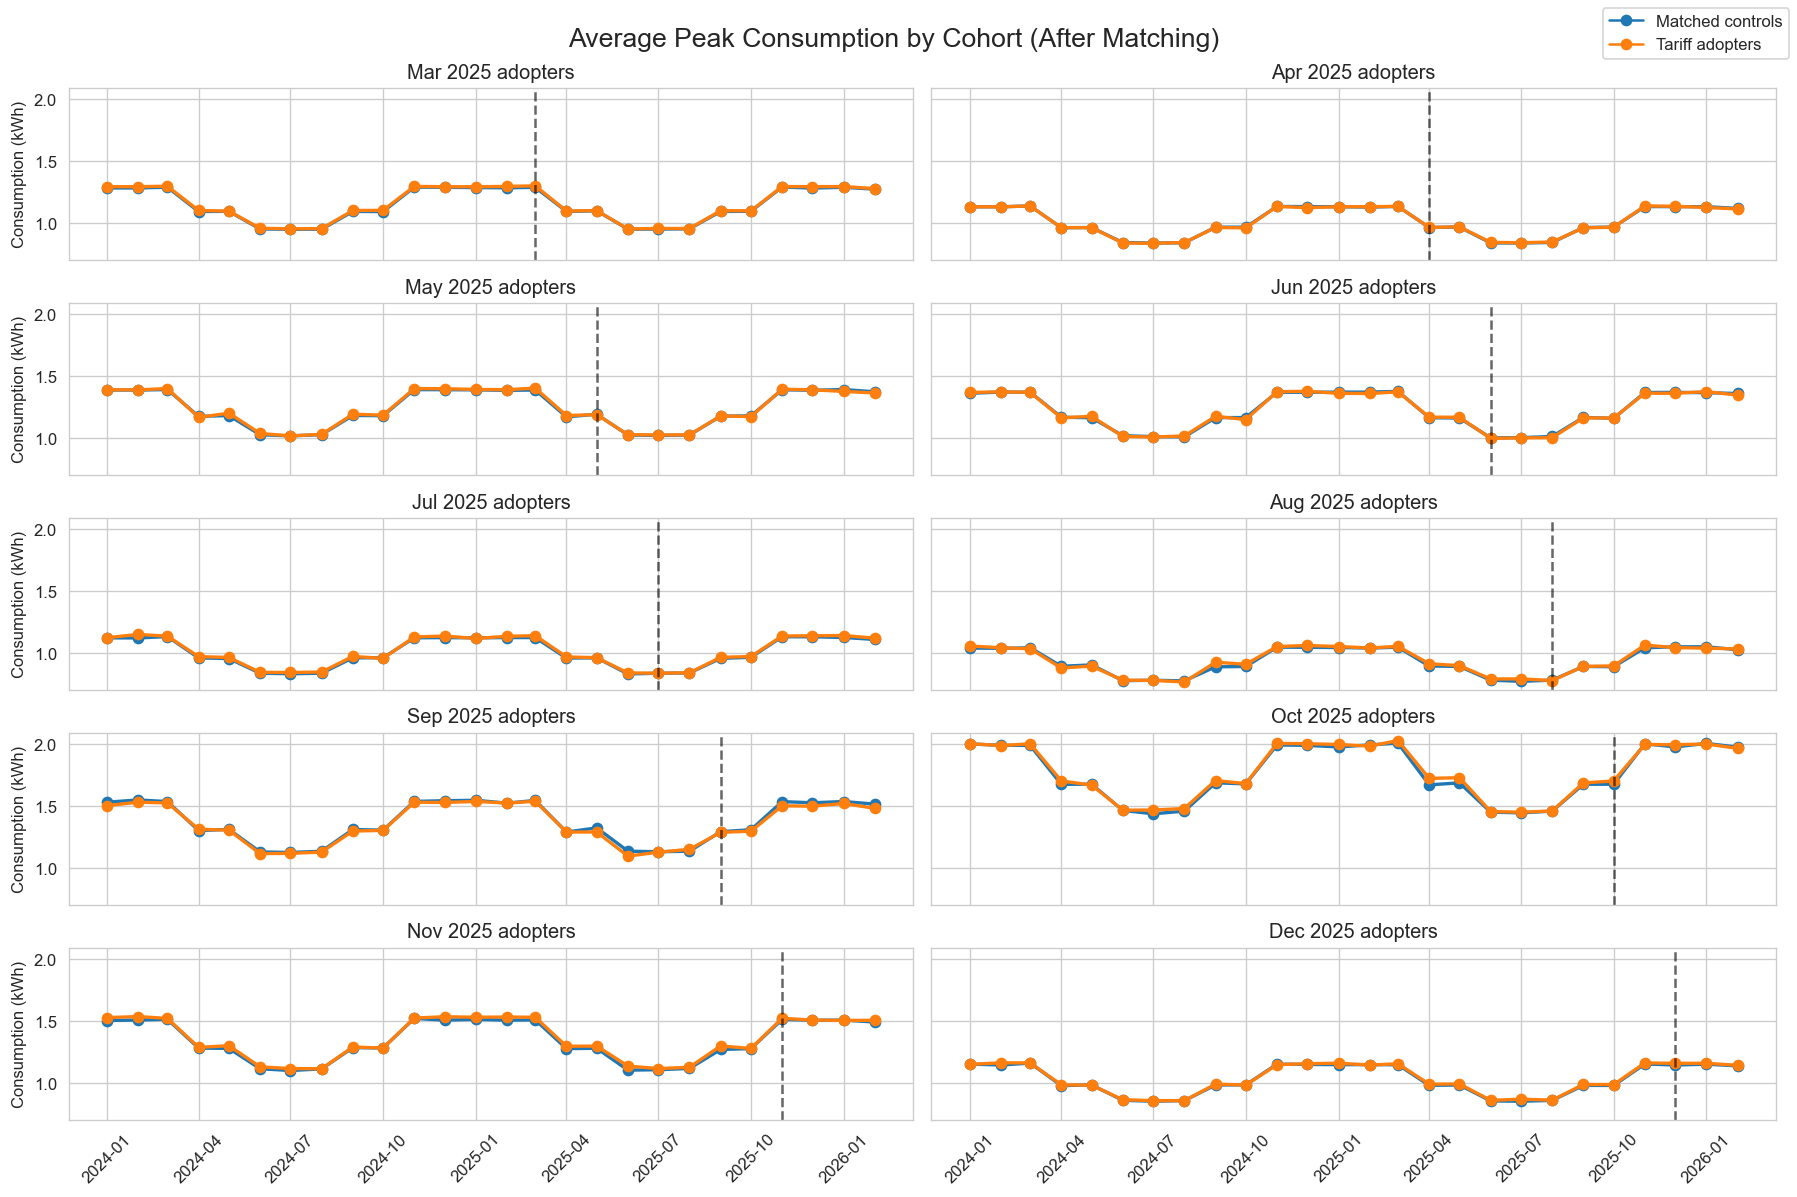

In [7]:
plot_cohort_panels(
    month_result[month_result["price"] == "all"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2,
    mode="matched"
)

array([<Axes: title={'center': 'Mar 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Apr 2025 adopters'}>,
       <Axes: title={'center': 'May 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Jun 2025 adopters'}>,
       <Axes: title={'center': 'Jul 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Aug 2025 adopters'}>,
       <Axes: title={'center': 'Sep 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Oct 2025 adopters'}>,
       <Axes: title={'center': 'Nov 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Dec 2025 adopters'}>], dtype=object)

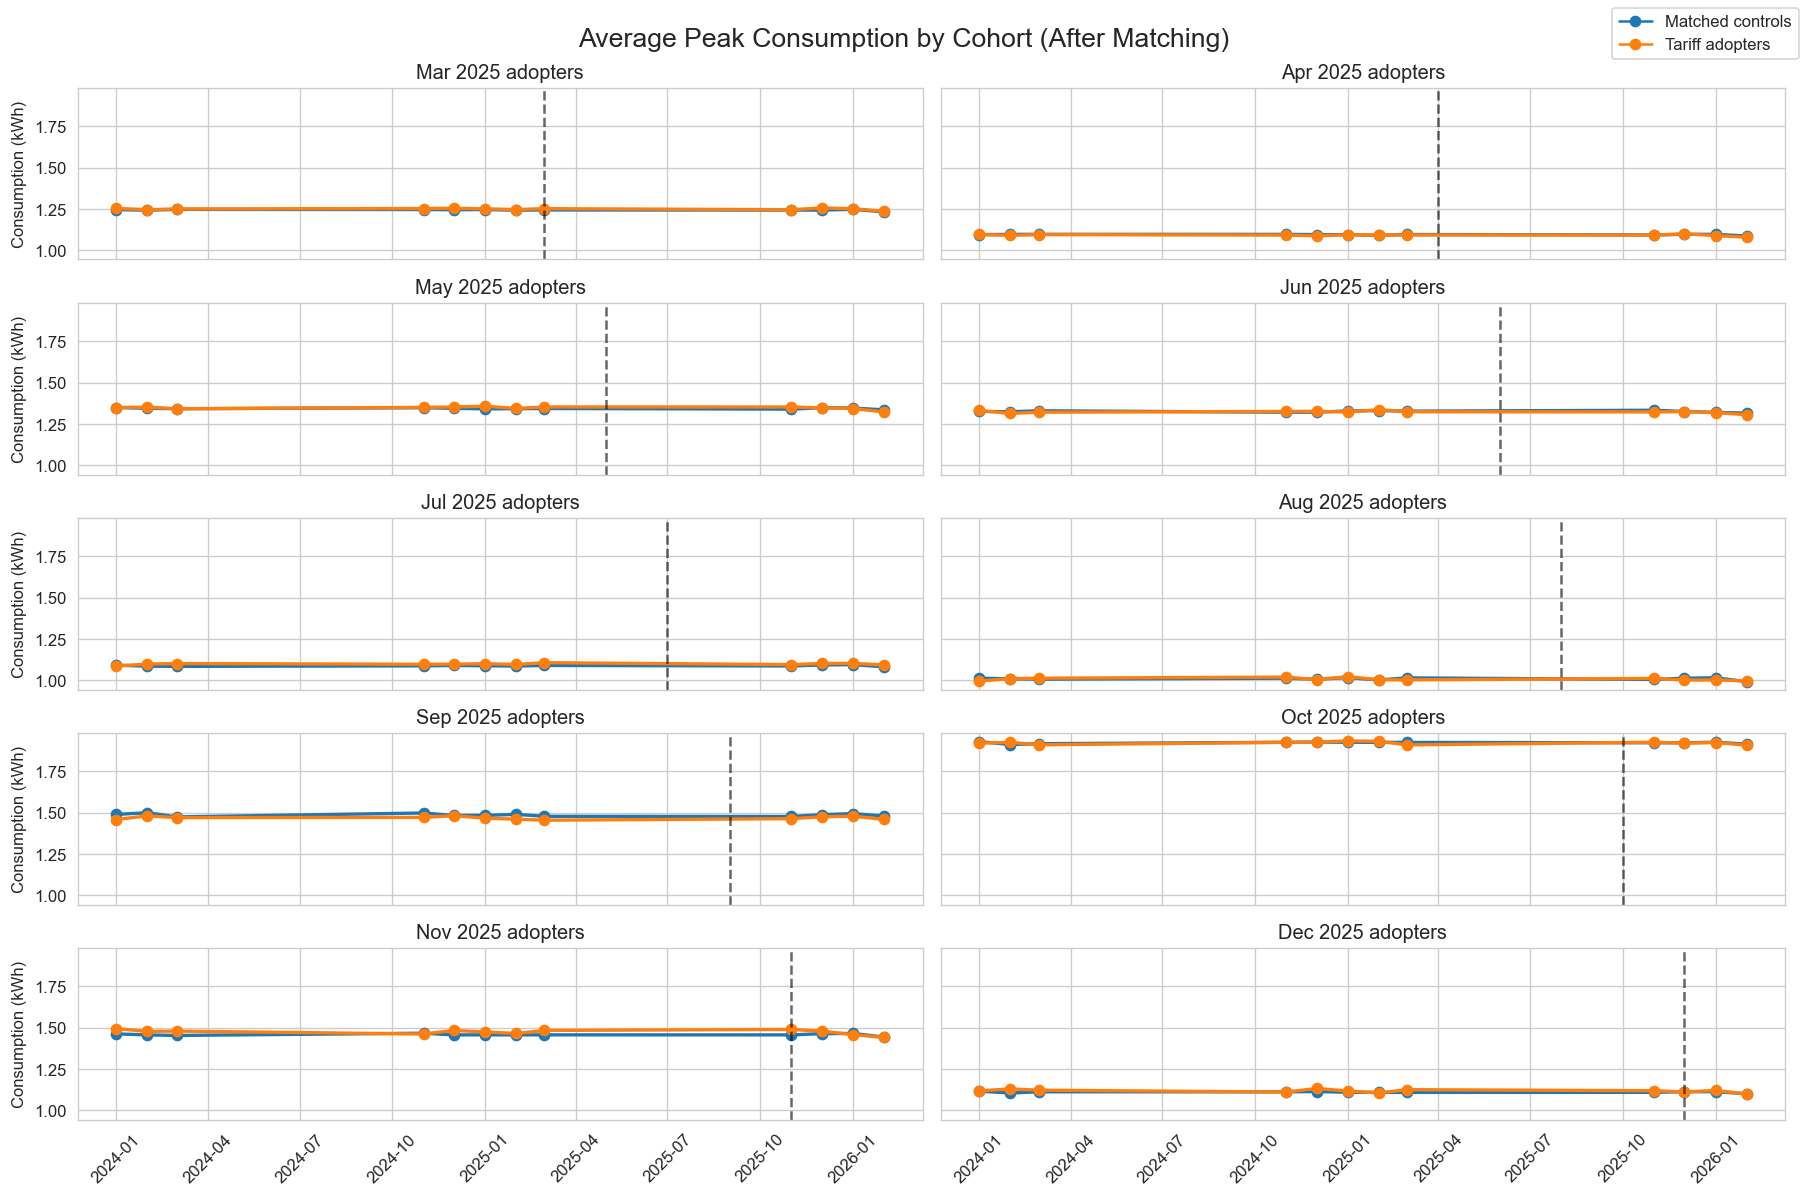

In [8]:
plot_cohort_panels(
    month_result[month_result["price"] == "high"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2,
    mode="matched"
)

array([<Axes: title={'center': 'Mar 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Apr 2025 adopters'}>,
       <Axes: title={'center': 'May 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Jun 2025 adopters'}>,
       <Axes: title={'center': 'Jul 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Aug 2025 adopters'}>,
       <Axes: title={'center': 'Sep 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Oct 2025 adopters'}>,
       <Axes: title={'center': 'Nov 2025 adopters'}, ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Dec 2025 adopters'}>], dtype=object)

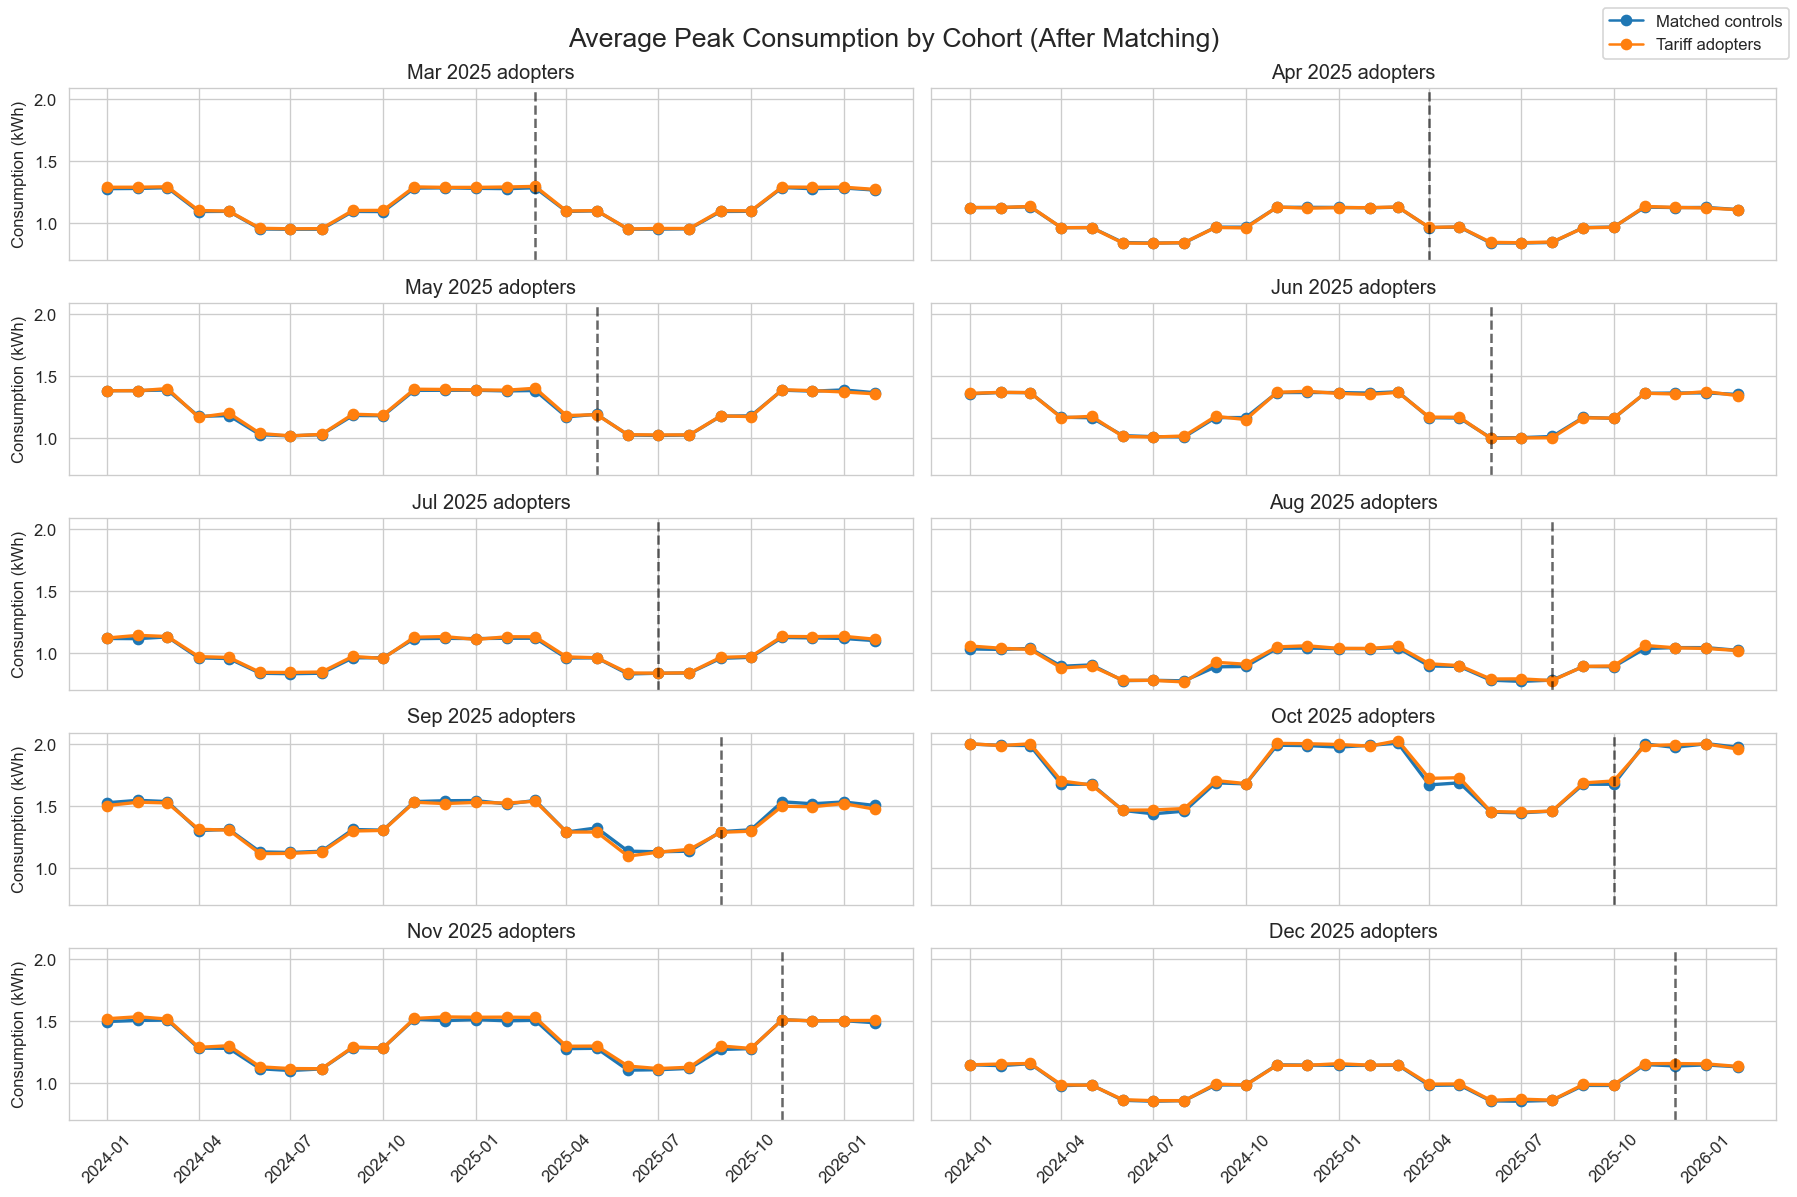

In [9]:
plot_cohort_panels(
    month_result[month_result["price"] == "low"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2,
    mode="matched"
)